In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

## Loading

In [ ]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_electron_loguniform/v1/runs/0/edm4hep.root"
batch = EDM4hepEventBatch(edm_input_file, events=(0, 10000), full_load=False, detector_params=detector_params)

In [17]:
tracker_hits = batch.get_tracker_hits_df()
calo_hits = batch.get_calo_hits_df()
calo_contributions = batch.get_calo_contributions_df()
particles = batch.get_particles_df()
print(f"""
Unique events IDs in particles: {particles.event_id.unique()}
Length of particles: {len(particles)}
Length of tracker_hits: {len(tracker_hits)}
Length of calo_hits: {len(calo_hits)}
Length of calo_contributions: {len(calo_contributions)}
Events with non-empty calo_hits: {calo_hits.event_id.unique()}
""")

KeyboardInterrupt: 

In [18]:
calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_electron_loguniform/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 10000), full_load=False, detector_params=detector_params)

In [19]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
# print(f"""
# Unique events IDs in particles: {particles.event_id.unique()}
# Length of particles: {len(particles)}
# Length of calo_tracker_hits: {len(calo_tracker_hits)}
# Length of calo_truth_hits: {len(calo_truth_hits)}
# Length of calo_digi_contributions: {len(calo_digi_contributions)}
# Length of calo_digi_hits: {len(calo_digi_hits)}
# Events with non-empty calo_digi_hits: {calo_digi_hits.event_id.unique()}
# """)

## Roadmap

1. What is the structure of calo digi file? A: Very similar to usual
2. Can we match truth calo cells to digitised cells? A: Yes, by cell ID
3. What is the residual on summed digitised energy vs generator energy? A: 
4. What is the digitised energy vs true cell energy?

In [20]:
print(f"Loaded {len(calo_digi_hits)} digitized calo hits")
print(f"\nColumns: {list(calo_digi_hits.columns)}")
print(f"\nDetectors: {calo_digi_hits['detector'].unique()}")
print(f"\nFirst few rows:")
print(calo_digi_hits.head())

# Verify all expected columns are present
expected_cols = ['cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 
                 'detector', 'r', 'R', 'phi', 'theta', 'eta', 'event_id']
missing_cols = set(expected_cols) - set(calo_digi_hits.columns)
if missing_cols:
    print(f"\nWARNING: Missing columns: {missing_cols}")
else:
    print(f"\n✓ All expected columns present")


Loaded 1252753 digitized calo hits

Columns: ['event_id', 'subentry', 'cellID', 'energy', 'energy_error', 'time', 'x', 'y', 'z', 'type', 'detector', 'r', 'R', 'phi', 'theta', 'eta']

Detectors: ['digiECalBarrelCollection' 'digiECalEndcapCollection'
 'digiHCalBarrelCollection' 'digiHCalEndcapCollection']

First few rows:
   event_id  subentry              cellID    energy  energy_error      time  \
0         5         0  125537663536476176  0.006438           0.0  0.179136   
1         6         0   73746340836491280  0.007310           0.0  3.072632   
2         6         1   74027815813267472  0.011830           0.0  3.070627   
3         6         2   74590770062049296  0.013380           0.0  3.082230   
4         6         3   75153728605667344  0.005875           0.0  3.099302   

             x            y            z    type                  detector  \
0 -1277.650024   209.100006  2269.500000   61010  digiECalBarrelCollection   
1  -834.739563  1007.839294  1331.099976  11101

In [8]:
calo_particles.iloc[1][["PDG", "vx", "vy", "vz", "px", "py", "pz", "energy"]]

PDG              11
vx              0.0
vy              0.0
vz              0.0
px        -0.271703
py          0.74433
pz       -13.002508
energy    13.026629
Name: 1, dtype: object

In [11]:
calo_digi_contributions

,event_id,subentry,energy,time,particle_id,detector
0,5,0,0.000172,8.788481,1,ECalBarrelCollection
1,6,0,0.000196,9.194777,1,ECalBarrelCollection
2,6,1,0.000314,9.216643,1,ECalBarrelCollection
3,6,2,0.000357,9.322108,1,ECalBarrelCollection
4,6,3,0.000158,9.408688,1,ECalBarrelCollection
...,...,...,...,...,...,...
32771885,996,53,0.000082,12.317056,161,HCalEndcapCollection
32771886,996,54,0.000008,936.715942,212,HCalEndcapCollection
32771887,996,55,0.000534,12.293084,222,HCalEndcapCollection
32771888,996,56,0.000146,12.296263,222,HCalEndcapCollection


In [12]:
calo_truth_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,5,0,125537663536476176,1.717500e-04,-1277.650024,209.100006,2269.500000,0,1,ECalBarrelCollection,1294.647583,2612.803467,2.979371,0.518412,1.327379
1,6,0,73746340836491280,1.955879e-04,-834.739563,1007.839294,1331.099976,0,1,ECalBarrelCollection,1308.636841,1866.643433,2.262525,0.776889,0.893459
2,6,1,74027815813267472,3.135537e-04,-838.310425,1011.410156,1336.199951,1,2,ECalBarrelCollection,1313.664673,1873.804932,2.262885,0.776894,0.893452
3,6,2,74590770062049296,3.574083e-04,-863.342041,1029.229248,1346.400024,2,3,ECalBarrelCollection,1343.380981,1901.963623,2.268766,0.784276,0.882962
4,6,3,75153728605667344,1.575240e-04,-884.838074,1036.300293,1356.599976,3,4,ECalBarrelCollection,1362.665283,1922.815674,2.277517,0.787629,0.878223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429464,996,17,18440270132077998612,1.823850e-09,1142.489136,120.000000,-3647.500000,45,46,HCalEndcapCollection,1148.773804,3824.125732,0.104650,2.836479,-1.872418
1429465,996,18,18432670333476610580,9.503015e-04,213.892105,-298.744904,-3647.500000,46,54,HCalEndcapCollection,367.421204,3665.958740,-0.949433,3.041199,-2.990963
1429466,996,19,18432951791274836500,7.566746e-06,213.892105,298.744904,-4718.500000,54,55,HCalEndcapCollection,367.421204,4732.783691,0.949433,3.063881,-3.247396
1429467,996,20,18433796237678420500,6.801995e-04,277.531708,-404.810944,-3647.500000,55,57,HCalEndcapCollection,490.811310,3680.373779,-0.969811,3.007835,-2.703382


In [13]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,5,0,125537663536476176,0.006445,0.0,0.179136,-1.277650e+03,209.100006,2269.500000,61010,digiECalBarrelCollection,1294.647583,2612.803467,2.979371,0.518412,1.327379
1,6,0,73746340836491280,0.007339,0.0,3.072632,-8.347396e+02,1007.839294,1331.099976,111010,digiECalBarrelCollection,1308.636841,1866.643433,2.262525,0.776889,0.893459
2,6,1,74027815813267472,0.011765,0.0,3.070627,-8.383104e+02,1011.410156,1336.199951,121010,digiECalBarrelCollection,1313.664673,1873.804932,2.262885,0.776894,0.893452
3,6,2,74590770062049296,0.013411,0.0,3.082230,-8.633420e+02,1029.229248,1346.400024,181010,digiECalBarrelCollection,1343.380981,1901.963623,2.268766,0.784276,0.882962
4,6,3,75153728605667344,0.005911,0.0,3.099302,-8.848381e+02,1036.300293,1356.599976,221010,digiECalBarrelCollection,1362.665283,1922.815674,2.277517,0.787629,0.878223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1253332,996,0,18436329503878947348,0.025074,0.0,0.503916,5.108770e+02,-553.303345,-3698.500000,22021,digiHCalEndcapCollection,753.086914,3774.392822,-0.825245,2.940719,-2.294857
1253333,996,1,18432670324887605780,0.022990,0.0,1.328285,-2.134699e-13,362.489105,-4361.500000,152021,digiHCalEndcapCollection,362.489105,4376.537598,1.570796,3.058672,-3.182447
1253334,996,2,18433796216203581972,0.020372,0.0,0.113609,2.285929e+02,-395.084412,-3647.500000,12021,digiHCalEndcapCollection,456.449768,3675.949219,-1.046266,3.017099,-2.775358
1253335,996,3,18432670333476610580,0.044593,0.0,0.164632,2.138921e+02,-298.744904,-3647.500000,12021,digiHCalEndcapCollection,367.421204,3665.958740,-0.949433,3.041199,-2.990963


In [21]:
generator_electrons = calo_particles[(calo_particles["PDG"] == 11) & (calo_particles["created_in_simulation"] == False)]

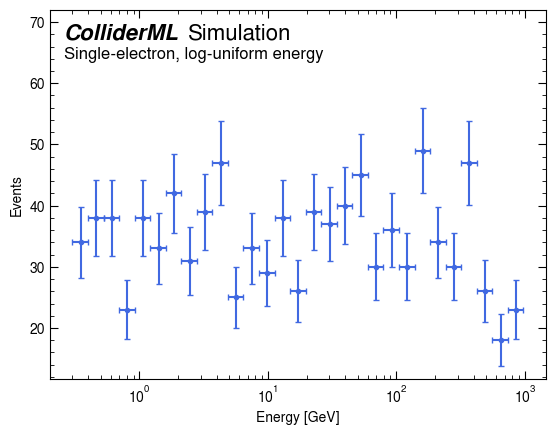

In [22]:
fig, ax = plt.subplots()
energy_data = generator_electrons["energy"]
log_bins = np.logspace(np.log10(energy_data.min()), np.log10(energy_data.max()), 30)
counts, bins = np.histogram(energy_data, bins=log_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Events')
ax.set_xscale('log')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-electron, log-uniform energy")

In [23]:
calo_digi_sum = calo_digi_hits.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")

In [ ]:
# merge the generator electrons with the calo digi sum
combined_electrons = generator_electrons.merge(calo_digi_sum, left_on="event_id", right_on="event_id", how="inner")
combined_electrons

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum
0,2,1,11,33554432,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.532331,1.531820,1,False,9,1,True,0.036311
1,4,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.316518,0.316007,1,False,10,81,True,0.247788
2,5,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.392895,0.392384,1,False,13,115,True,0.411645
3,6,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,0.343148,0.342637,1,False,13,26,True,0.311164
4,7,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.170465,1.169954,1,False,14,236,True,1.249798
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,995,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,46.359856,46.359345,1,False,11,675,True,43.910133
948,996,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,46.401099,46.400588,1,False,12,607,True,45.859158
949,997,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,31.481206,31.480695,1,False,15,95,True,31.820776
950,998,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1,0.0,1.083552,1.083041,1,False,14,85,True,0.453685


In [ ]:
def calculate_eta(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log((p + pz) / (p - pz))

combined_electrons["eta"] = calculate_eta(combined_electrons["px"], combined_electrons["py"], combined_electrons["pz"])
combined_electrons["pt"] = np.sqrt(combined_electrons["px"]**2 + combined_electrons["py"]**2)
combined_electrons

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,created_inside_tracker,energy_sum,eta,pt
0,2,1,11,33554432,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.532331,1.531820,1,False,9,1,True,0.036311,-3.402071,0.101953
1,4,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.316518,0.316007,1,False,10,81,True,0.247788,-2.353778,0.059606
2,5,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.392895,0.392384,1,False,13,115,True,0.411645,1.307977,0.197979
3,6,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,0.343148,0.342637,1,False,13,26,True,0.311164,0.590723,0.290899
4,7,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.170465,1.169954,1,False,14,236,True,1.249798,0.264651,1.130638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,995,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,46.359856,46.359345,1,False,11,675,True,43.910133,1.186314,25.896958
948,996,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,46.401099,46.400588,1,False,12,607,True,45.859158,-2.767541,5.806579
949,997,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,31.481206,31.480695,1,False,15,95,True,31.820776,2.078250,7.758175
950,998,1,11,16777216,-1.0,0.0,0.000511,0.0,0.0,0.0,...,1.083552,1.083041,1,False,14,85,True,0.453685,-1.006060,0.698962


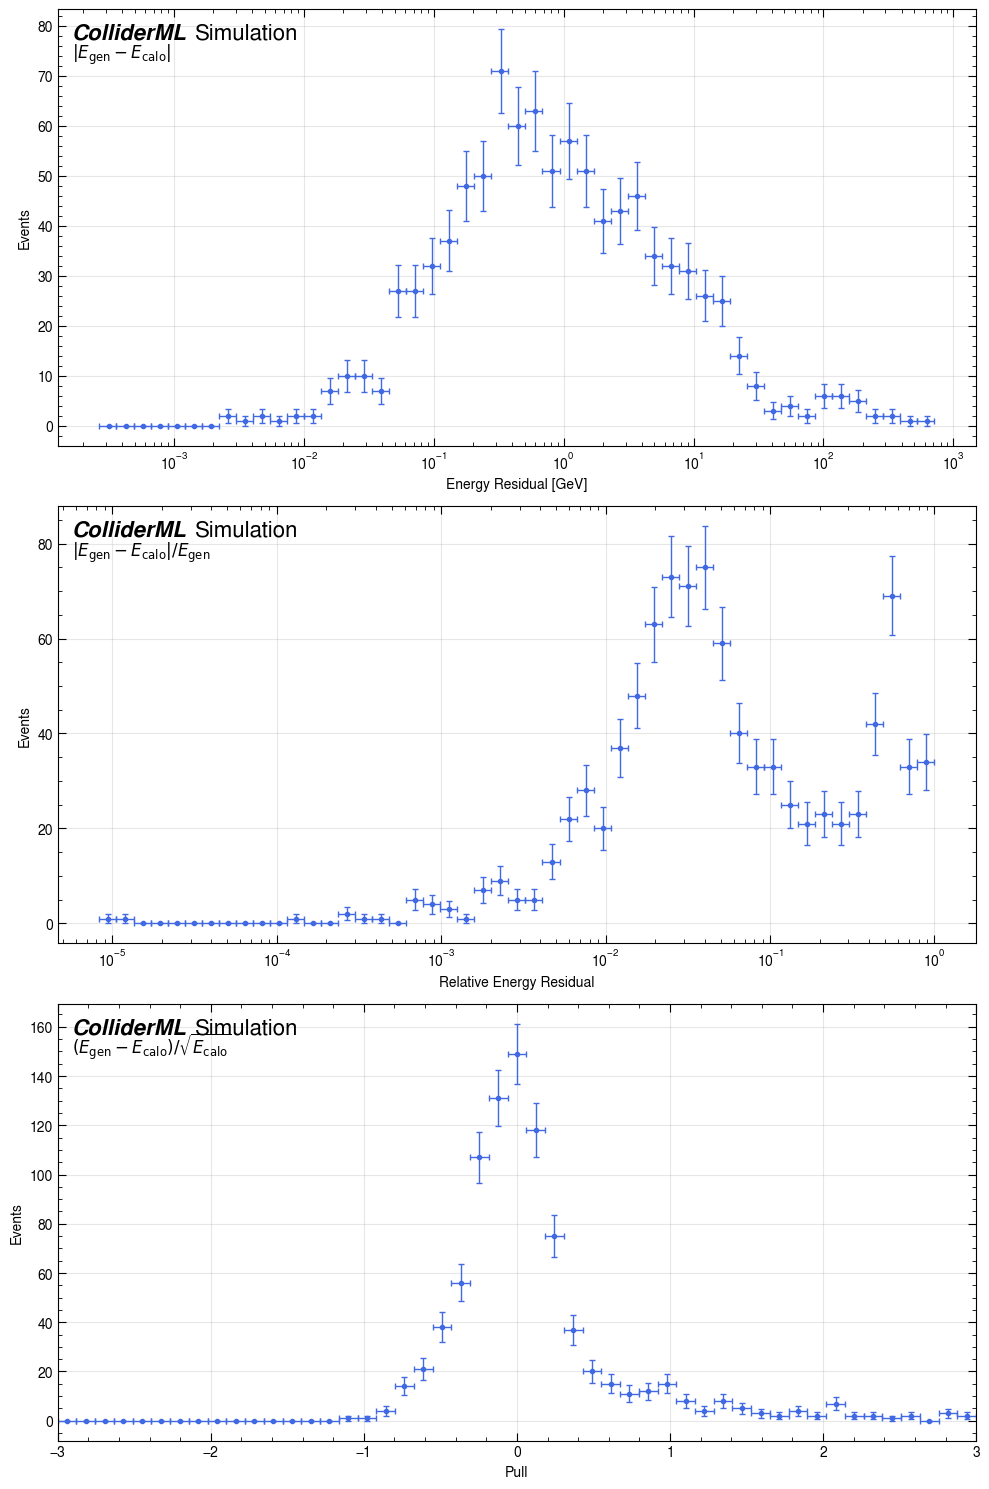

In [ ]:
residual = (combined_electrons["energy"] - combined_electrons["energy_sum"]).abs()
relative_residual = residual / combined_electrons["energy"]
pull = (combined_electrons["energy"] - combined_electrons["energy_sum"]) / np.sqrt(combined_electrons["energy_sum"])
# Set pull to 0 where energy_sum is 0
pull[combined_electrons["energy_sum"] == 0] = 0

# Create high-quality ATLAS-style plot with error bars
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Absolute residual with log x-axis
bins_residual = np.logspace(np.log10(residual[residual > 0].min()), np.log10(residual.max()), 50)
counts, bins = np.histogram(residual, bins=bins_residual)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[0].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[0].set_xlabel('Energy Residual [GeV]')
ax[0].set_ylabel('Events')
ax[0].set_xscale('log')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}|$", axes=ax[0], enlarge=1.0)

# Plot 2: Relative residual with log x-axis
bins_relative = np.logspace(np.log10(relative_residual[relative_residual > 0].min()), 
                             np.log10(relative_residual.max()), 50)
counts, bins = np.histogram(relative_residual, bins=bins_relative)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[1].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[1].set_xlabel('Relative Energy Residual')
ax[1].set_ylabel('Events')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$", axes=ax[1], enlarge=1.0)

# Plot 3: Pull distribution (linear x-axis is more appropriate for pulls)
bins_pull = np.linspace(-3, 3, 50)
counts, bins = np.histogram(pull, bins=bins_pull)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[2].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[2].set_xlabel('Pull')
ax[2].set_ylabel('Events')
# Set x-axis limits to -3 to 3
ax[2].set_xlim(-3, 3)
ax[2].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$(E_{\mathrm{gen}} - E_{\mathrm{calo}}) / \sqrt{E_{\mathrm{calo}}}$", axes=ax[2], enlarge=1.0)

plt.tight_layout()

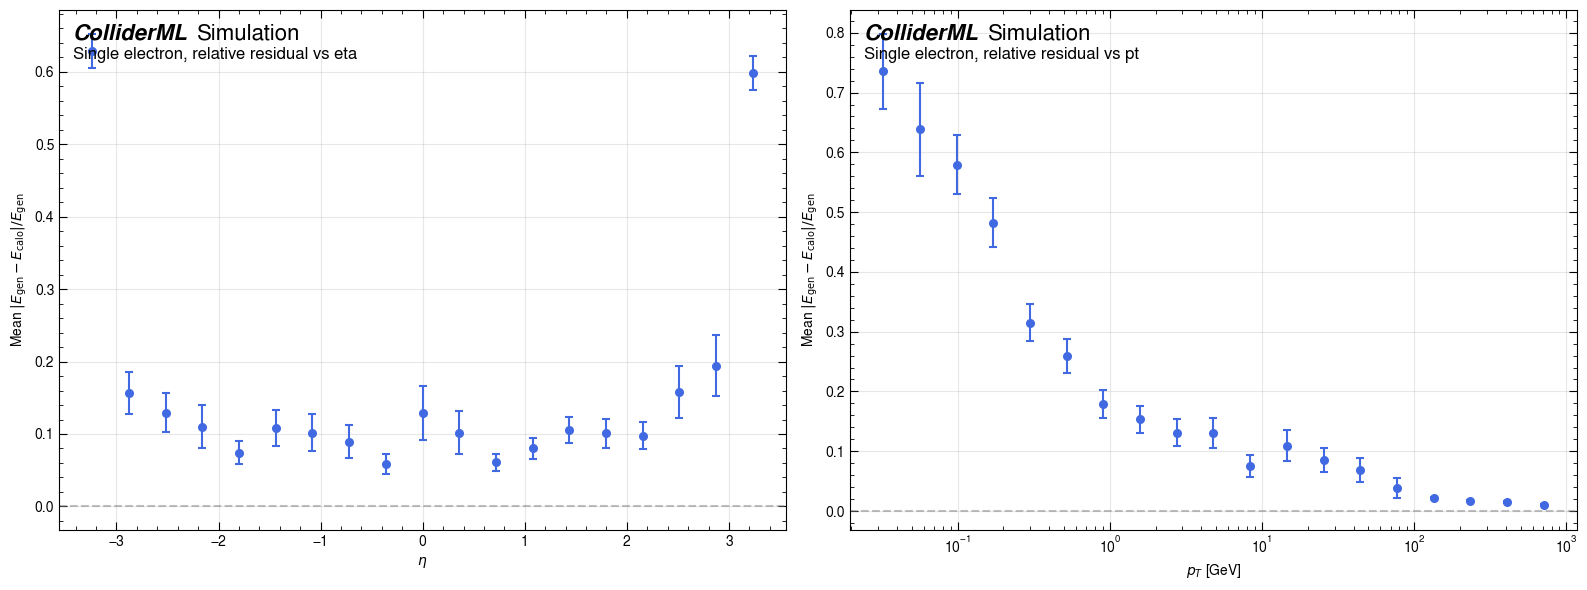

In [ ]:
# Profile plots: Mean relative residual vs eta and pt
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Profile 1: Mean relative residual vs eta
eta_bins = np.linspace(combined_electrons['eta'].min(), combined_electrons['eta'].max(), 20)
eta_bin_centers = []
eta_bin_widths = []
eta_mean_residuals = []
eta_errors = []

for i in range(len(eta_bins)-1):
    mask = (combined_electrons['eta'] >= eta_bins[i]) & (combined_electrons['eta'] < eta_bins[i+1])
    if mask.sum() > 0:
        eta_bin_centers.append((eta_bins[i] + eta_bins[i+1]) / 2)
        eta_bin_widths.append(eta_bins[i+1] - eta_bins[i])
        residuals_in_bin = relative_residual[mask]
        eta_mean_residuals.append(residuals_in_bin.mean())
        eta_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[0].errorbar(eta_bin_centers, eta_mean_residuals, xerr=eta_bin_widths/2, yerr=eta_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[0].set_xlabel(r'$\eta$')
ax[0].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs eta", axes=ax[0], enlarge=1.0)

# Profile 2: Mean relative residual vs pt (log scale)
pt_bins = np.logspace(np.log10(combined_electrons['pt'].min()), 
                       np.log10(combined_electrons['pt'].max()), 20)
pt_bin_centers = []
pt_bin_widths = []
pt_mean_residuals = []
pt_errors = []

for i in range(len(pt_bins)-1):
    mask = (combined_electrons['pt'] >= pt_bins[i]) & (combined_electrons['pt'] < pt_bins[i+1])
    if mask.sum() > 0:
        # Use geometric mean for bin center in log space
        pt_bin_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))
        pt_bin_widths.append(pt_bins[i+1] - pt_bins[i])
        residuals_in_bin = relative_residual[mask]
        pt_mean_residuals.append(residuals_in_bin.mean())
        pt_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[1].errorbar(pt_bin_centers, pt_mean_residuals, xerr=pt_bin_widths/2, yerr=pt_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[1].set_xlabel(r'$p_T$ [GeV]')
ax[1].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs pt", axes=ax[1], enlarge=1.0)

plt.tight_layout()

## Pion Sample

In [3]:
calo_digi_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion_loguniform/v1/runs/0/edm4hep_digitized.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 1000), full_load=False)

In [4]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
print(f"""
Unique events IDs in particles: {calo_particles.event_id.unique()}
Length of particles: {len(calo_particles)}
Length of calo_tracker_hits: {len(calo_tracker_hits)}
Length of calo_truth_hits: {len(calo_truth_hits)}
Length of calo_digi_contributions: {len(calo_digi_contributions)}
Length of calo_digi_hits: {len(calo_digi_hits)}
Events with non-empty calo_digi_hits: {len(calo_digi_hits.event_id.unique())}
""")

Augmenting particle hit counts with tracker hits

Unique events IDs in particles: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 2

In [5]:
generator_pions = calo_particles[(calo_particles["PDG"] == -211) & (calo_particles["created_in_simulation"] == False)]

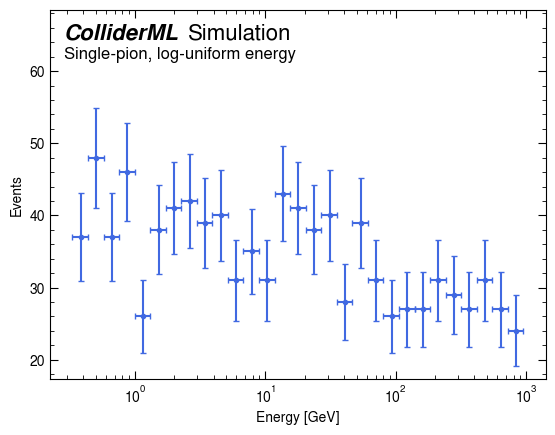

In [6]:
fig, ax = plt.subplots()
energy_data = generator_pions["energy"]
log_bins = np.logspace(np.log10(energy_data.min()), np.log10(energy_data.max()), 30)
counts, bins = np.histogram(energy_data, bins=log_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Events')
ax.set_xscale('log')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-pion, log-uniform energy")

In [7]:
calo_digi_sum = calo_digi_hits.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")

In [8]:
# merge the generator pions with the calo digi sum
combined_pions = generator_pions.merge(calo_digi_sum, left_on="event_id", right_on="event_id", how="inner")
combined_pions

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,energy_sum
0,2,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,0.369432,0.229862,1,False,12,33,0.102118
1,3,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,0.406686,0.267116,1,False,6,67,0.149011
2,4,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,0.389603,0.250033,1,False,10,120,0.140634
3,5,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,1.187428,1.047858,1,False,14,81,0.974460
4,6,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,1.238775,1.099204,1,False,14,173,0.871869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922,995,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,148.389915,148.250345,1,False,14,2006,53.985962
923,996,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,519.870046,519.730476,1,False,16,1455,264.054779
924,997,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,321.934451,321.794881,1,False,11,1999,254.799606
925,998,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,1,0.0,19.778375,19.638805,1,False,13,923,17.769060


In [9]:
combined_pions = combined_pions[(combined_pions.energy < 50) & (combined_pions.energy > 5)]

In [11]:
def calculate_eta(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log((p + pz) / (p - pz))

combined_pions["eta"] = calculate_eta(combined_pions["px"], combined_pions["py"], combined_pions["pz"])
combined_pions["pt"] = np.sqrt(combined_pions["px"]**2 + combined_pions["py"]**2)
combined_pions

/tmp/ipykernel_2142039/3280308098.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_pions["eta"] = calculate_eta(combined_pions["px"], combined_pions["py"], combined_pions["pz"])
/tmp/ipykernel_2142039/3280308098.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_pions["pt"] = np.sqrt(combined_pions["px"]**2 + combined_pions["py"]**2)


,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,energy_sum,eta,pt
17,20,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,6.479094,6.339524,1,False,2,0,4.042663,-2.678114,0.885745
18,21,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,20.402389,20.262818,1,False,12,465,9.218349,2.671177,2.808991
20,23,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,20.301172,20.161602,1,False,17,1255,11.116351,-0.245919,19.701937
21,24,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,12.510850,12.371279,1,False,13,156,6.729138,-1.617017,4.778003
22,25,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,26.858450,26.718879,1,False,12,447,11.895354,2.881651,3.000945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,983,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,42.112785,41.973215,1,False,11,547,28.550940,1.000689,27.276904
918,991,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,11.444096,11.304525,1,False,11,430,4.557639,2.380336,2.099474
919,992,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.790693,9.651123,1,False,14,584,6.625795,-0.268569,9.446944
925,998,1,-211,16777216,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,19.778375,19.638805,1,False,13,923,17.769060,1.693362,7.036349


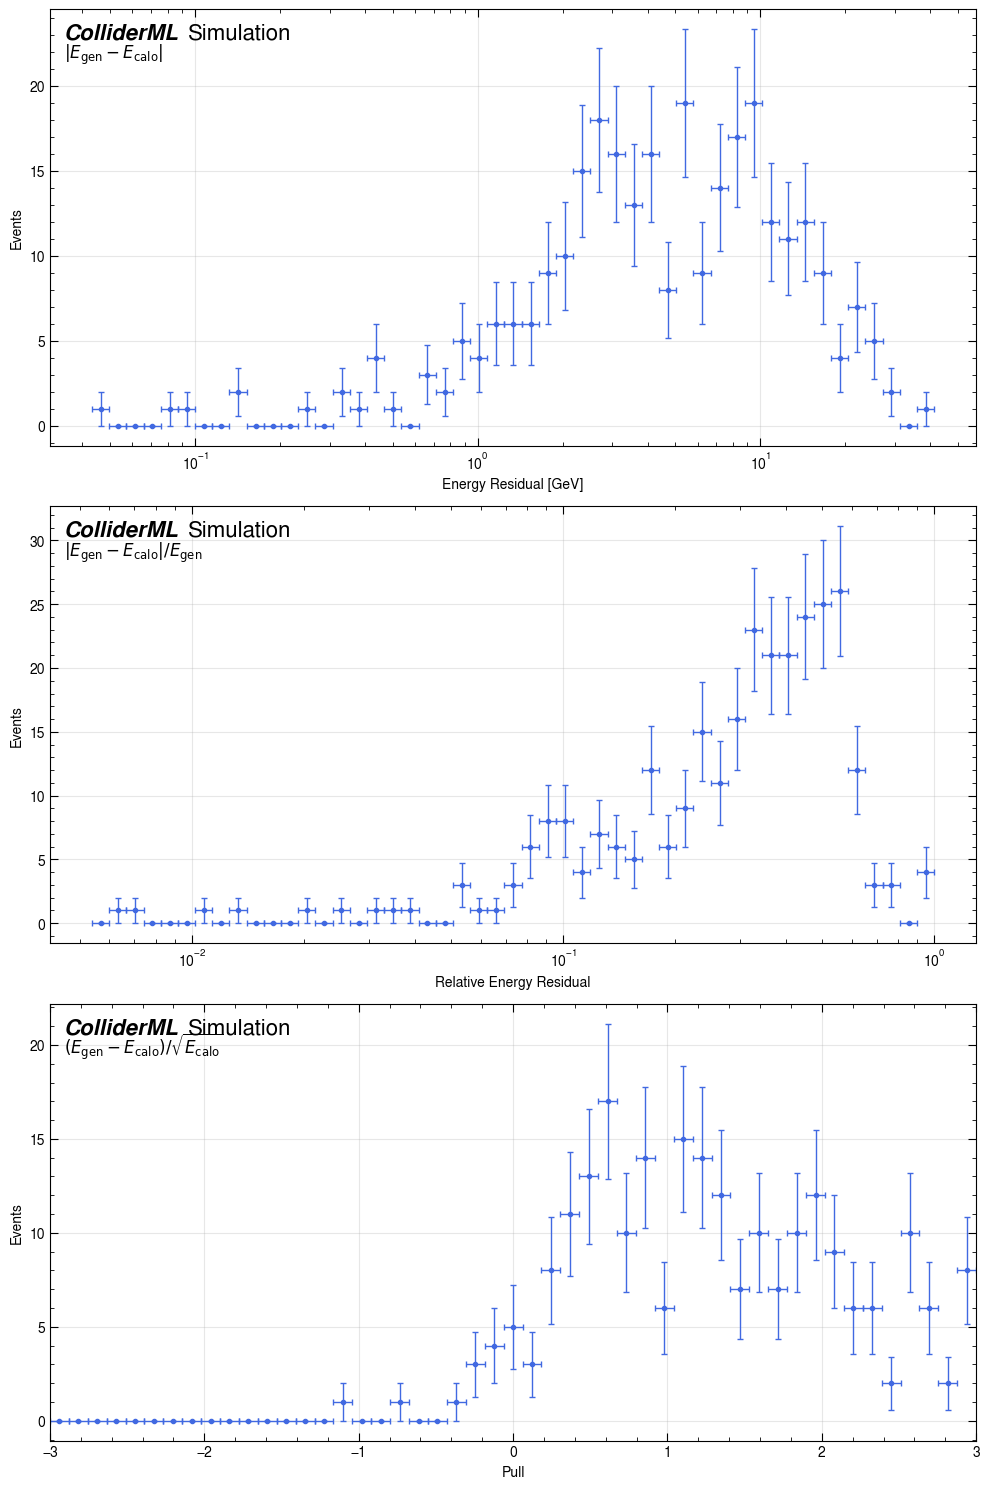

In [13]:
residual = (combined_pions["energy"] - combined_pions["energy_sum"]).abs()
relative_residual = residual / combined_pions["energy"]
pull = (combined_pions["energy"] - combined_pions["energy_sum"]) / np.sqrt(combined_pions["energy_sum"])
# Set pull to 0 where energy_sum is 0
pull[combined_pions["energy_sum"] == 0] = 0

# Create high-quality ATLAS-style plot with error bars
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Absolute residual with log x-axis
bins_residual = np.logspace(np.log10(residual[residual > 0].min()), np.log10(residual.max()), 50)
counts, bins = np.histogram(residual, bins=bins_residual)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[0].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[0].set_xlabel('Energy Residual [GeV]')
ax[0].set_ylabel('Events')
ax[0].set_xscale('log')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}|$", axes=ax[0], enlarge=1.0)

# Plot 2: Relative residual with log x-axis
bins_relative = np.logspace(np.log10(relative_residual[relative_residual > 0].min()), 
                             np.log10(relative_residual.max()), 50)
counts, bins = np.histogram(relative_residual, bins=bins_relative)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[1].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[1].set_xlabel('Relative Energy Residual')
ax[1].set_ylabel('Events')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$", axes=ax[1], enlarge=1.0)

# Plot 3: Pull distribution (linear x-axis is more appropriate for pulls)
bins_pull = np.linspace(-3, 3, 50)
counts, bins = np.histogram(pull, bins=bins_pull)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[2].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[2].set_xlabel('Pull')
ax[2].set_ylabel('Events')
# Set x-axis limits to -3 to 3
ax[2].set_xlim(-3, 3)
ax[2].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$(E_{\mathrm{gen}} - E_{\mathrm{calo}}) / \sqrt{E_{\mathrm{calo}}}$", axes=ax[2], enlarge=1.0)

plt.tight_layout()

NameError: name 'combined_electrons' is not defined

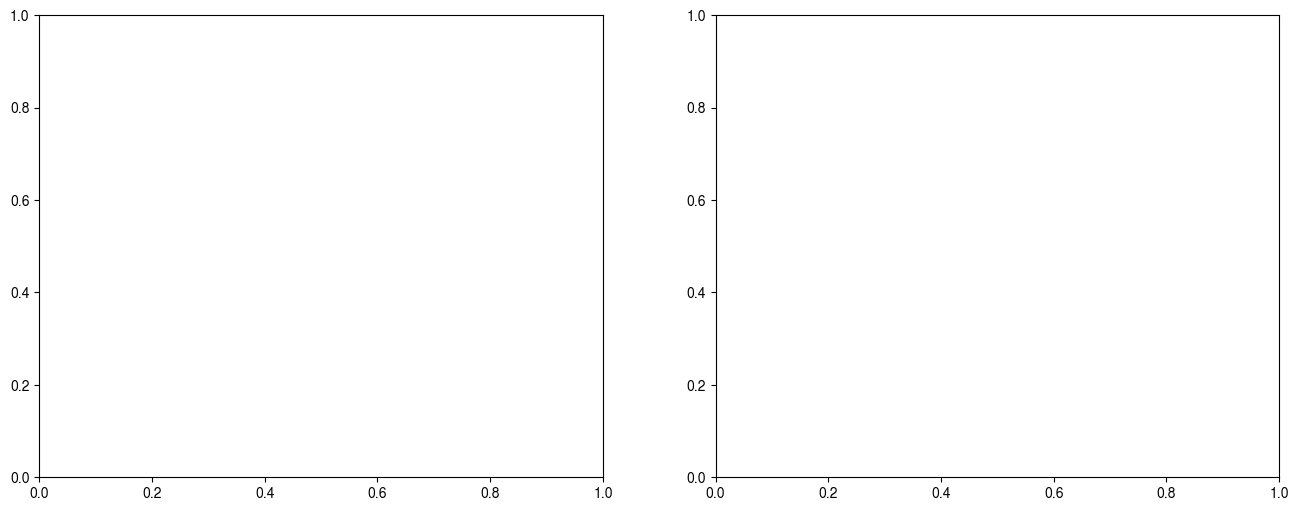

In [14]:
# Profile plots: Mean relative residual vs eta and pt
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Profile 1: Mean relative residual vs eta
eta_bins = np.linspace(combined_electrons['eta'].min(), combined_electrons['eta'].max(), 20)
eta_bin_centers = []
eta_bin_widths = []
eta_mean_residuals = []
eta_errors = []

for i in range(len(eta_bins)-1):
    mask = (combined_electrons['eta'] >= eta_bins[i]) & (combined_electrons['eta'] < eta_bins[i+1])
    if mask.sum() > 0:
        eta_bin_centers.append((eta_bins[i] + eta_bins[i+1]) / 2)
        eta_bin_widths.append(eta_bins[i+1] - eta_bins[i])
        residuals_in_bin = relative_residual[mask]
        eta_mean_residuals.append(residuals_in_bin.mean())
        eta_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[0].errorbar(eta_bin_centers, eta_mean_residuals, xerr=eta_bin_widths/2, yerr=eta_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[0].set_xlabel(r'$\eta$')
ax[0].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs eta", axes=ax[0], enlarge=1.0)

# Profile 2: Mean relative residual vs pt (log scale)
pt_bins = np.logspace(np.log10(combined_electrons['pt'].min()), 
                       np.log10(combined_electrons['pt'].max()), 20)
pt_bin_centers = []
pt_bin_widths = []
pt_mean_residuals = []
pt_errors = []

for i in range(len(pt_bins)-1):
    mask = (combined_electrons['pt'] >= pt_bins[i]) & (combined_electrons['pt'] < pt_bins[i+1])
    if mask.sum() > 0:
        # Use geometric mean for bin center in log space
        pt_bin_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))
        pt_bin_widths.append(pt_bins[i+1] - pt_bins[i])
        residuals_in_bin = relative_residual[mask]
        pt_mean_residuals.append(residuals_in_bin.mean())
        pt_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[1].errorbar(pt_bin_centers, pt_mean_residuals, xerr=pt_bin_widths/2, yerr=pt_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[1].set_xlabel(r'$p_T$ [GeV]')
ax[1].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs pt", axes=ax[1], enlarge=1.0)

plt.tight_layout()

## CLD Sample

In [8]:
import uproot

# Open the file and inspect its structure
with uproot.open(calo_digi_file) as file:
    print("Available trees:")
    for key in file.keys():
        print(f"  {key}")
    
    # Get the events tree
    if "events" in file:
        tree = file["events"]
        print(f"\nBranches in 'events' tree:")
        for branch_name in tree.keys():
            print(f"  {branch_name}")
        
        print(f"\nNumber of entries: {tree.num_entries}")


Available trees:
  events;3
  events;2
  configuration_metadata;1
  metadata;1
  podio_metadata;1

Branches in 'events' tree:
  BuildUpVertices
  BuildUpVertices/BuildUpVertices.type
  BuildUpVertices/BuildUpVertices.chi2
  BuildUpVertices/BuildUpVertices.ndf
  BuildUpVertices/BuildUpVertices.position.x
  BuildUpVertices/BuildUpVertices.position.y
  BuildUpVertices/BuildUpVertices.position.z
  BuildUpVertices/BuildUpVertices.covMatrix.values[6]
  BuildUpVertices/BuildUpVertices.algorithmType
  BuildUpVertices/BuildUpVertices.parameters_begin
  BuildUpVertices/BuildUpVertices.parameters_end
  BuildUpVertices/BuildUpVertices.particles_begin
  BuildUpVertices/BuildUpVertices.particles_end
  _BuildUpVertices_particles
  _BuildUpVertices_particles/_BuildUpVertices_particles.index
  _BuildUpVertices_particles/_BuildUpVertices_particles.collectionID
  _BuildUpVertices_parameters
  BuildUpVertices_associatedParticles
  BuildUpVertices_associatedParticles/BuildUpVertices_associatedParticles.wei

In [33]:
calo_digi_file = "FCCeeCLD_1000ev_theta70to110deg_phi0to360deg_10GeV_REC.edm4hep.root"
calo_batch = EDM4hepEventBatch(calo_digi_file, events=(0, 1000), full_load=False)

In [34]:
calo_tracker_hits = calo_batch.get_tracker_hits_df()
calo_truth_hits = calo_batch.get_calo_hits_df()
calo_digi_hits = calo_batch.get_digi_calo_hits_df()
calo_digi_contributions = calo_batch.get_calo_contributions_df()
calo_particles = calo_batch.get_particles_df()
print(f"""
Unique events IDs in particles: {calo_particles.event_id.unique()}
Length of particles: {len(calo_particles)}
Length of calo_tracker_hits: {len(calo_tracker_hits)}
Length of calo_truth_hits: {len(calo_truth_hits)}
Length of calo_digi_contributions: {len(calo_digi_contributions)}
Length of calo_digi_hits: {len(calo_digi_hits)}
""")


Unique events IDs in particles: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 2

In [35]:
calo_particles

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,-211,83886080,-1.0,0.000000,0.139570,0.000000,0.000000,0.000000,...,1.056668,0,0,0.000000,9.908947,9.769377,0,False,0,1578
1,0,1,11,1493172224,-1.0,0.044346,0.000511,-8.135413,10.417287,1.417642,...,0.001096,0,1,13.217595,0.001542,0.001031,1,True,0,0
2,1,0,-211,83886080,-1.0,0.000000,0.139570,0.000000,0.000000,0.000000,...,-1.752671,0,0,0.000000,10.083924,9.944354,0,False,0,2779
3,1,1,2212,1493172224,1.0,42.034981,0.938272,1059.759741,1586.062970,-295.120500,...,0.016025,0,1,1907.534129,0.939294,0.001022,1,True,0,0
4,1,2,2212,1493172224,1.0,58.421150,0.938272,1265.728594,1334.520272,1622.185579,...,0.090499,1,2,1839.296939,0.945313,0.007041,2,True,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4847,997,1,11,1493172224,-1.0,0.050906,0.000511,-13.394755,5.245358,-5.092085,...,-0.001865,0,1,14.385175,0.002295,0.001784,1,True,0,0
4848,998,0,-211,83886080,-1.0,0.000000,0.139570,0.000000,0.000000,0.000000,...,-3.231546,0,0,0.000000,9.866007,9.726437,0,False,0,2421
4849,999,0,-211,83886080,-1.0,0.000000,0.139570,0.000000,0.000000,0.000000,...,2.628579,0,0,0.000000,10.038294,9.898723,0,False,0,2386
4850,999,1,2212,1493172224,1.0,131.112915,0.938272,-633.109347,266.353707,1042.336270,...,-0.027611,0,1,686.856421,0.940600,0.002328,1,True,0,0


In [36]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,0,0,12948226885813268,0.006110,0.0,0.112113,-1464.872192,1639.633057,234.600006,1010,ECALBarrel,2198.692139,2211.172607,2.299961,1.464499,0.106498
1,0,1,12948226886337556,0.007800,0.0,0.113330,-1467.397217,1644.006470,234.600006,11010,ECALBarrel,2203.635986,2216.088623,2.299493,1.464735,0.106260
2,0,2,12948226886861844,0.004771,0.0,0.114540,-1469.922241,1648.379883,234.600006,21010,ECALBarrel,2208.580566,2221.005371,2.299028,1.464971,0.106023
3,0,3,13229706159064084,0.007720,0.0,0.110502,-1476.863892,1650.203369,239.699997,31010,ECALBarrel,2214.564941,2227.499512,2.300819,1.462978,0.108028
4,0,4,13229706159588372,0.007346,0.0,0.111740,-1479.388916,1654.576782,239.699997,41010,ECALBarrel,2219.508057,2232.413818,2.300353,1.463216,0.107788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244288,15,4,1688909991903275,0.033872,0.0,8.151754,-65.162651,452.276276,2666.000000,42021,HCALEndcap,456.946381,2704.876221,1.713889,0.169748,2.464180
244289,15,5,1688914287394859,0.052225,0.0,8.182147,-57.398079,481.254059,2692.500000,52021,HCALEndcap,484.664856,2735.773438,1.689503,0.178098,2.415919
244290,649,0,18441677829071437899,0.064708,0.0,2.867969,-29.684620,-2197.184326,-2560.000000,2021,HCALEndcap,2197.384766,3373.736816,-1.584306,2.432269,-0.993386
244291,649,1,18441677824777519179,0.252345,0.0,4.252673,-21.920048,-2168.206543,-2613.000000,22021,HCALEndcap,2168.317383,3395.492432,-1.580906,2.448932,-1.019222


In [37]:
calo_truth_hits

,event_id,subentry,cellID,energy,x,y,z,contribution_begin,contribution_end,detector,r,R,phi,theta,eta
0,0,0,12948226885813268,1.628390e-04,-1464.872192,1639.633057,234.600006,0,1,ECalBarrelCollection,2198.692139,2211.172607,2.299961,1.464499,0.106498
1,0,1,12948226886337556,2.078822e-04,-1467.397217,1644.006470,234.600006,1,2,ECalBarrelCollection,2203.635986,2216.088623,2.299493,1.464735,0.106260
2,0,2,12948226886861844,1.271518e-04,-1469.922241,1648.379883,234.600006,2,3,ECalBarrelCollection,2208.580566,2221.005371,2.299028,1.464971,0.106023
3,0,3,13229706159064084,2.057309e-04,-1476.863892,1650.203369,239.699997,3,4,ECalBarrelCollection,2214.564941,2227.499512,2.300819,1.462978,0.108028
4,0,4,13229706159588372,1.957862e-04,-1479.388916,1654.576782,239.699997,4,5,ECalBarrelCollection,2219.508057,2232.413818,2.300353,1.463216,0.107788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791975,997,7,33495444927545419,6.616506e-09,-3279.615234,1437.819336,-2984.000000,15,17,HCalEndcapCollection,3580.949707,4661.271973,2.728418,2.265514,-0.758460
791976,997,8,32369480588853323,3.318789e-04,-3047.235352,1841.427734,-2613.000000,17,30,HCalEndcapCollection,3560.407227,4416.363770,2.598022,2.203917,-0.680221
791977,997,9,33214021487296587,2.122925e-04,-3343.812256,1082.321533,-2825.000000,30,32,HCalEndcapCollection,3514.612305,4509.226562,2.828556,2.247842,-0.735623
791978,997,10,32932546510585931,2.892883e-05,-3314.834473,1074.556885,-2825.000000,32,37,HCalEndcapCollection,3484.652100,4485.914062,2.828115,2.252027,-0.741000


In [38]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,0,0,12948226885813268,0.006110,0.0,0.112113,-1464.872192,1639.633057,234.600006,1010,ECALBarrel,2198.692139,2211.172607,2.299961,1.464499,0.106498
1,0,1,12948226886337556,0.007800,0.0,0.113330,-1467.397217,1644.006470,234.600006,11010,ECALBarrel,2203.635986,2216.088623,2.299493,1.464735,0.106260
2,0,2,12948226886861844,0.004771,0.0,0.114540,-1469.922241,1648.379883,234.600006,21010,ECALBarrel,2208.580566,2221.005371,2.299028,1.464971,0.106023
3,0,3,13229706159064084,0.007720,0.0,0.110502,-1476.863892,1650.203369,239.699997,31010,ECALBarrel,2214.564941,2227.499512,2.300819,1.462978,0.108028
4,0,4,13229706159588372,0.007346,0.0,0.111740,-1479.388916,1654.576782,239.699997,41010,ECALBarrel,2219.508057,2232.413818,2.300353,1.463216,0.107788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
244288,15,4,1688909991903275,0.033872,0.0,8.151754,-65.162651,452.276276,2666.000000,42021,HCALEndcap,456.946381,2704.876221,1.713889,0.169748,2.464180
244289,15,5,1688914287394859,0.052225,0.0,8.182147,-57.398079,481.254059,2692.500000,52021,HCALEndcap,484.664856,2735.773438,1.689503,0.178098,2.415919
244290,649,0,18441677829071437899,0.064708,0.0,2.867969,-29.684620,-2197.184326,-2560.000000,2021,HCALEndcap,2197.384766,3373.736816,-1.584306,2.432269,-0.993386
244291,649,1,18441677824777519179,0.252345,0.0,4.252673,-21.920048,-2168.206543,-2613.000000,22021,HCALEndcap,2168.317383,3395.492432,-1.580906,2.448932,-1.019222


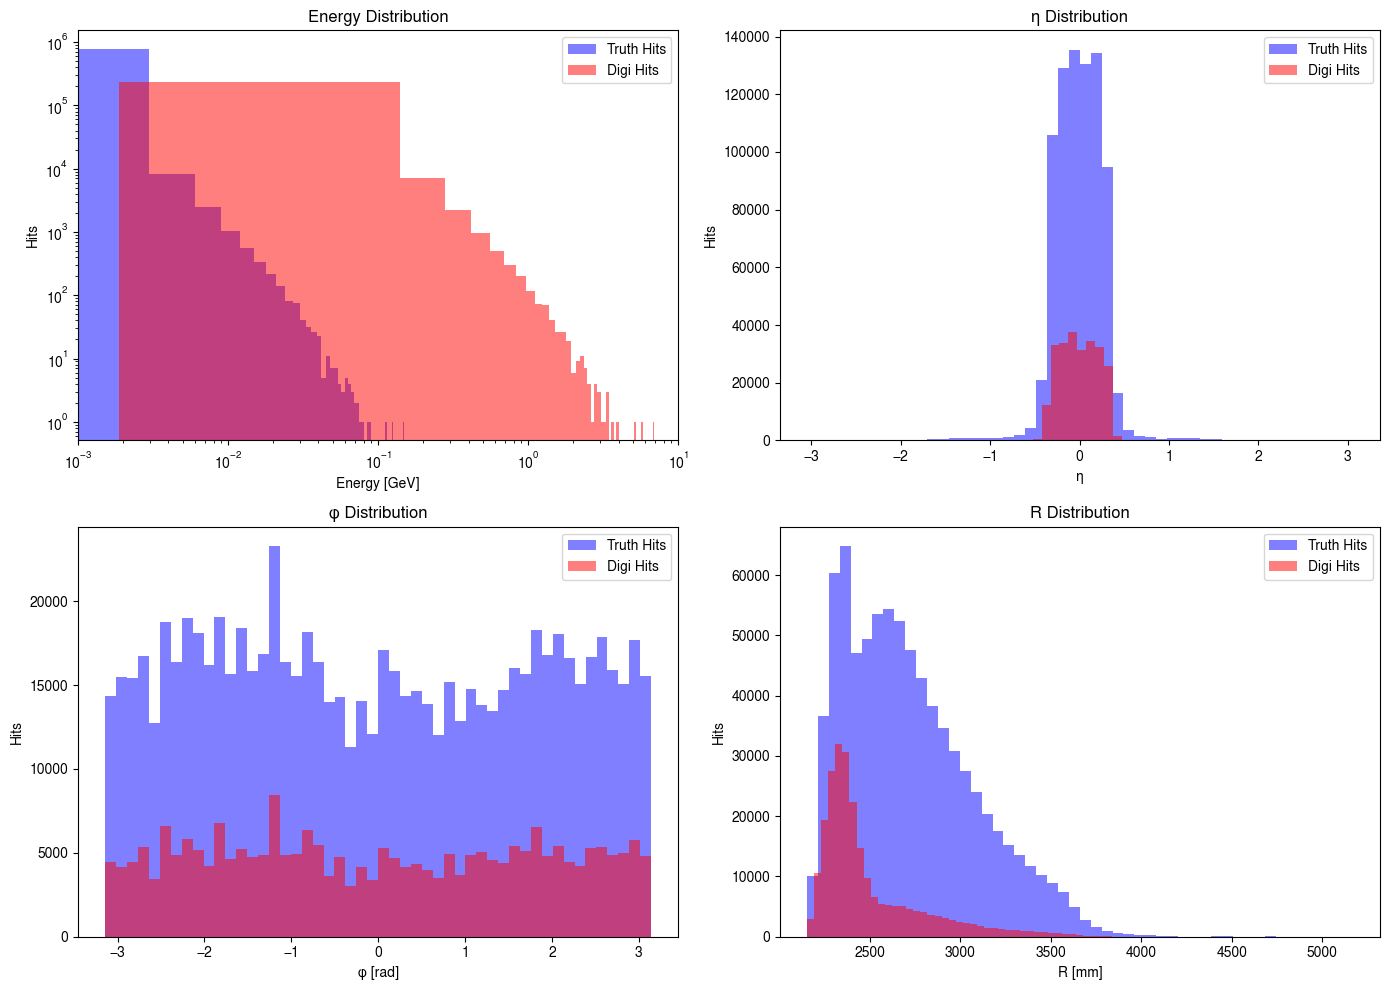

In [39]:
# Compare truth hits vs digi hits distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energy distribution
ax = axes[0, 0]
ax.hist(calo_truth_hits["energy"], bins=50, alpha=0.5, label="Truth Hits", color='blue')
ax.hist(calo_digi_hits["energy"], bins=50, alpha=0.5, label="Digi Hits", color='red')
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Hits')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xbound(0.001, 10)
ax.legend()
ax.set_title('Energy Distribution')

# Eta distribution
ax = axes[0, 1]
ax.hist(calo_truth_hits["eta"], bins=50, alpha=0.5, label="Truth Hits", color='blue')
ax.hist(calo_digi_hits["eta"], bins=50, alpha=0.5, label="Digi Hits", color='red')
ax.set_xlabel('η')
ax.set_ylabel('Hits')
ax.legend()
ax.set_title('η Distribution')

# Phi distribution
ax = axes[1, 0]
ax.hist(calo_truth_hits["phi"], bins=50, alpha=0.5, label="Truth Hits", color='blue')
ax.hist(calo_digi_hits["phi"], bins=50, alpha=0.5, label="Digi Hits", color='red')
ax.set_xlabel('φ [rad]')
ax.set_ylabel('Hits')
ax.legend()
ax.set_title('φ Distribution')

# R distribution
ax = axes[1, 1]
ax.hist(calo_truth_hits["R"], bins=50, alpha=0.5, label="Truth Hits", color='blue')
ax.hist(calo_digi_hits["R"], bins=50, alpha=0.5, label="Digi Hits", color='red')
ax.set_xlabel('R [mm]')
ax.set_ylabel('Hits')
ax.legend()
ax.set_title('R Distribution')

plt.tight_layout()
plt.show()



In [40]:
generator_pions = calo_particles[(calo_particles["PDG"] == -211) & (calo_particles["created_in_simulation"] == False)]

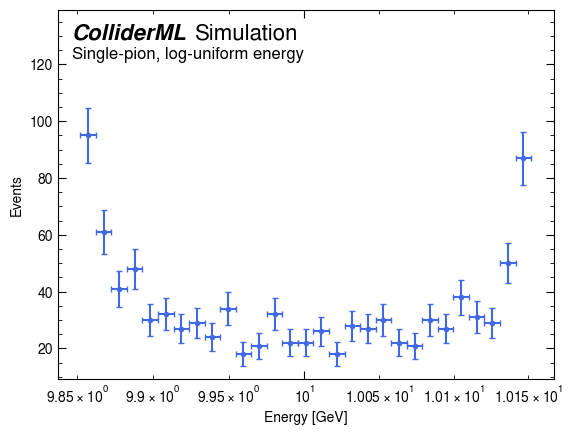

In [41]:
fig, ax = plt.subplots()
energy_data = generator_pions["energy"]
log_bins = np.logspace(np.log10(energy_data.min()), np.log10(energy_data.max()), 30)
counts, bins = np.histogram(energy_data, bins=log_bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Energy [GeV]')
ax.set_ylabel('Events')
ax.set_xscale('log')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-pion, log-uniform energy")

In [42]:
calo_digi_sum = calo_digi_hits.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")

In [43]:
# merge the generator pions with the calo digi sum
combined_pions = generator_pions.merge(calo_digi_sum, left_on="event_id", right_on="event_id", how="inner")
combined_pions

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,energy_sum
0,0,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.908947,9.769377,0,False,0,1578,9.186795
1,1,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,10.083924,9.944354,0,False,0,2779,8.541356
2,2,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,10.117729,9.978159,0,False,0,2138,9.939168
3,3,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.858401,9.718831,0,False,0,1847,10.376661
4,4,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.993904,9.854334,0,False,0,3039,8.157065
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.864769,9.725199,0,False,0,1782,12.468369
996,996,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,10.151162,10.011592,0,False,0,1962,10.339480
997,997,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.869936,9.730365,0,False,0,1873,10.344090
998,998,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0,0,0.0,9.866007,9.726437,0,False,0,2421,11.773726


In [44]:
def calculate_eta(px, py, pz):
    p = np.sqrt(px**2 + py**2 + pz**2)
    return 0.5 * np.log((p + pz) / (p - pz))

combined_pions["eta"] = calculate_eta(combined_pions["px"], combined_pions["py"], combined_pions["pz"])
combined_pions["pt"] = np.sqrt(combined_pions["px"]**2 + combined_pions["py"]**2)
combined_pions

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits,energy_sum,eta,pt
0,0,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.908947,9.769377,0,False,0,1578,9.186795,0.107056,9.851457
1,1,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,10.083924,9.944354,0,False,0,2779,8.541356,-0.175608,9.929461
2,2,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,10.117729,9.978159,0,False,0,2138,9.939168,0.000245,10.116766
3,3,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.858401,9.718831,0,False,0,1847,10.376661,-0.289640,9.457913
4,4,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.993904,9.854334,0,False,0,3039,8.157065,-0.269664,9.640286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.864769,9.725199,0,False,0,1782,12.468369,-0.177598,9.710242
996,996,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,10.151162,10.011592,0,False,0,1962,10.339480,0.022506,10.147633
997,997,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.869936,9.730365,0,False,0,1873,10.344090,-0.346954,9.303353
998,998,0,-211,83886080,-1.0,0.0,0.13957,0.0,0.0,0.0,...,0.0,9.866007,9.726437,0,False,0,2421,11.773726,-0.340111,9.320715


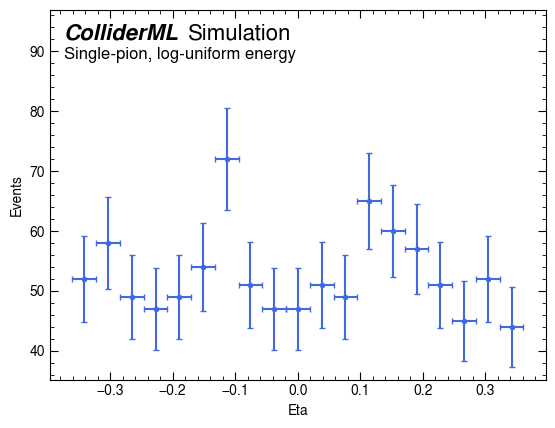

In [46]:
fig, ax = plt.subplots()
eta_data = combined_pions["eta"]
eta_bins = np.linspace(combined_pions['eta'].min(), combined_pions['eta'].max(), 20)
counts, bins = np.histogram(eta_data, bins=eta_bins)
bin_centers = (eta_bins[:-1] + eta_bins[1:]) / 2
bin_widths = eta_bins[1:] - eta_bins[:-1]
errors = np.sqrt(counts)
ax.errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, fmt='o', color='royalblue', capsize=2, markersize=3)
ax.set_xlabel('Eta')
ax.set_ylabel('Events')
# ax.set_yscale('log')
atl.atlasify("Simulation","Single-pion, log-uniform energy")

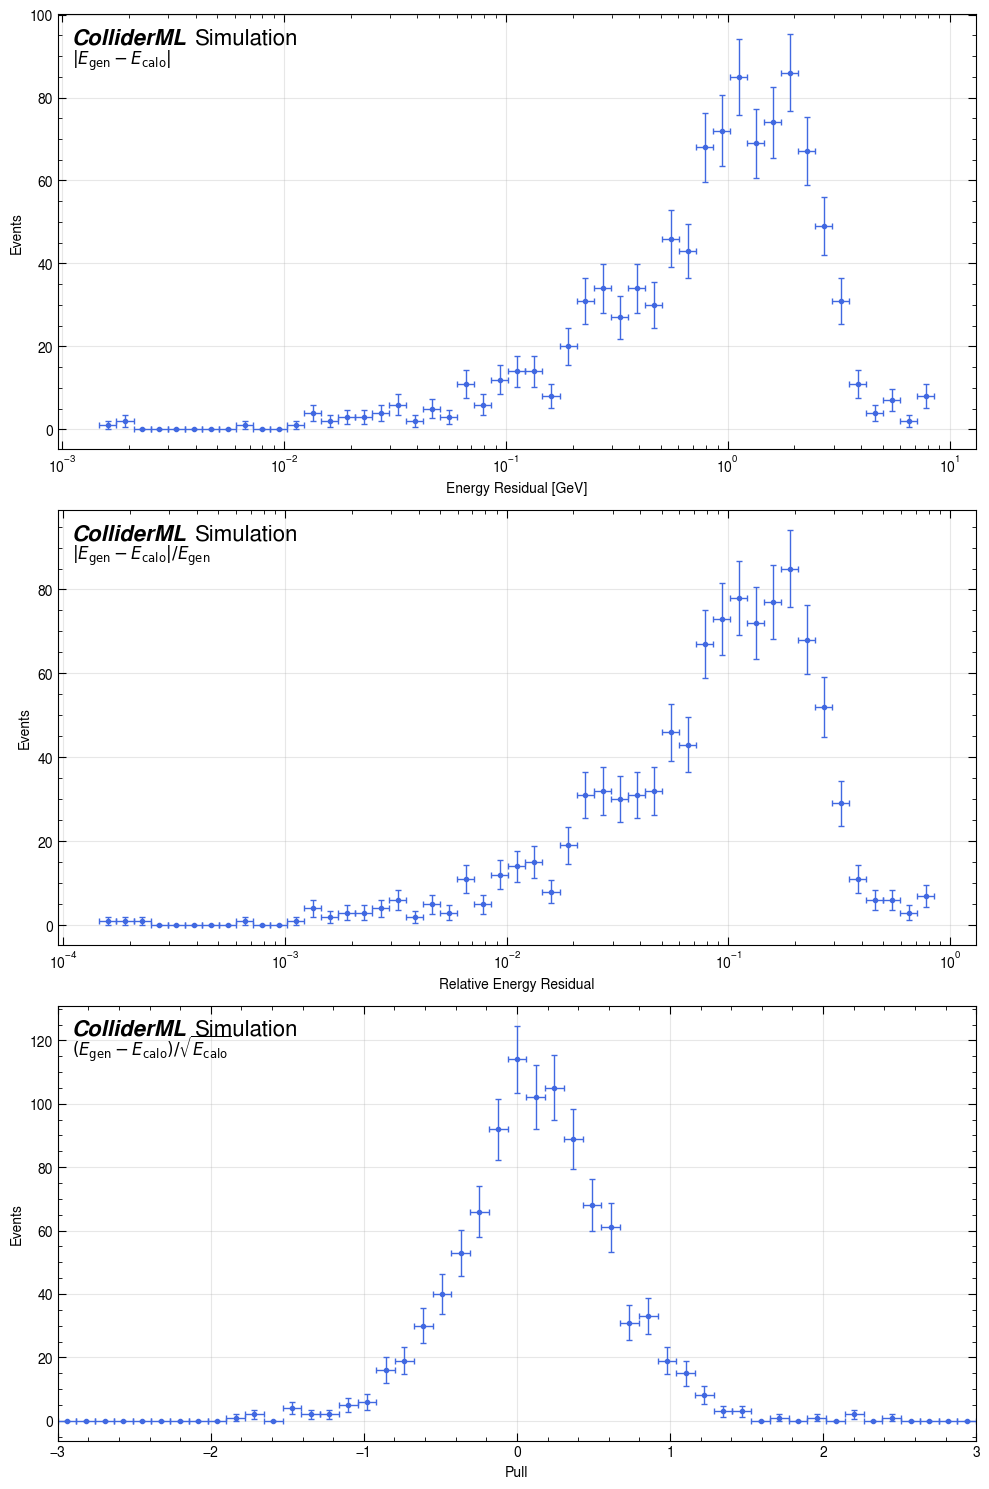

In [47]:
residual = (combined_pions["energy"] - combined_pions["energy_sum"]).abs()
relative_residual = residual / combined_pions["energy"]
pull = (combined_pions["energy"] - combined_pions["energy_sum"]) / np.sqrt(combined_pions["energy_sum"])
# Set pull to 0 where energy_sum is 0
pull[combined_pions["energy_sum"] == 0] = 0

# Create high-quality ATLAS-style plot with error bars
fig, ax = plt.subplots(3, 1, figsize=(10, 15))

# Plot 1: Absolute residual with log x-axis
bins_residual = np.logspace(np.log10(residual[residual > 0].min()), np.log10(residual.max()), 50)
counts, bins = np.histogram(residual, bins=bins_residual)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[0].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[0].set_xlabel('Energy Residual [GeV]')
ax[0].set_ylabel('Events')
ax[0].set_xscale('log')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}|$", axes=ax[0], enlarge=1.0)

# Plot 2: Relative residual with log x-axis
bins_relative = np.logspace(np.log10(relative_residual[relative_residual > 0].min()), 
                             np.log10(relative_residual.max()), 50)
counts, bins = np.histogram(relative_residual, bins=bins_relative)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[1].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[1].set_xlabel('Relative Energy Residual')
ax[1].set_ylabel('Events')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$", axes=ax[1], enlarge=1.0)

# Plot 3: Pull distribution (linear x-axis is more appropriate for pulls)
bins_pull = np.linspace(-3, 3, 50)
counts, bins = np.histogram(pull, bins=bins_pull)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_widths = bins[1:] - bins[:-1]
errors = np.sqrt(counts)

ax[2].errorbar(bin_centers, counts, xerr=bin_widths/2, yerr=errors, 
               fmt='o', color='royalblue', capsize=2, markersize=3, 
               elinewidth=1, markeredgewidth=1)
ax[2].set_xlabel('Pull')
ax[2].set_ylabel('Events')
# Set x-axis limits to -3 to 3
ax[2].set_xlim(-3, 3)
ax[2].grid(True, alpha=0.3)
atl.atlasify("Simulation", r"$(E_{\mathrm{gen}} - E_{\mathrm{calo}}) / \sqrt{E_{\mathrm{calo}}}$", axes=ax[2], enlarge=1.0)

plt.tight_layout()

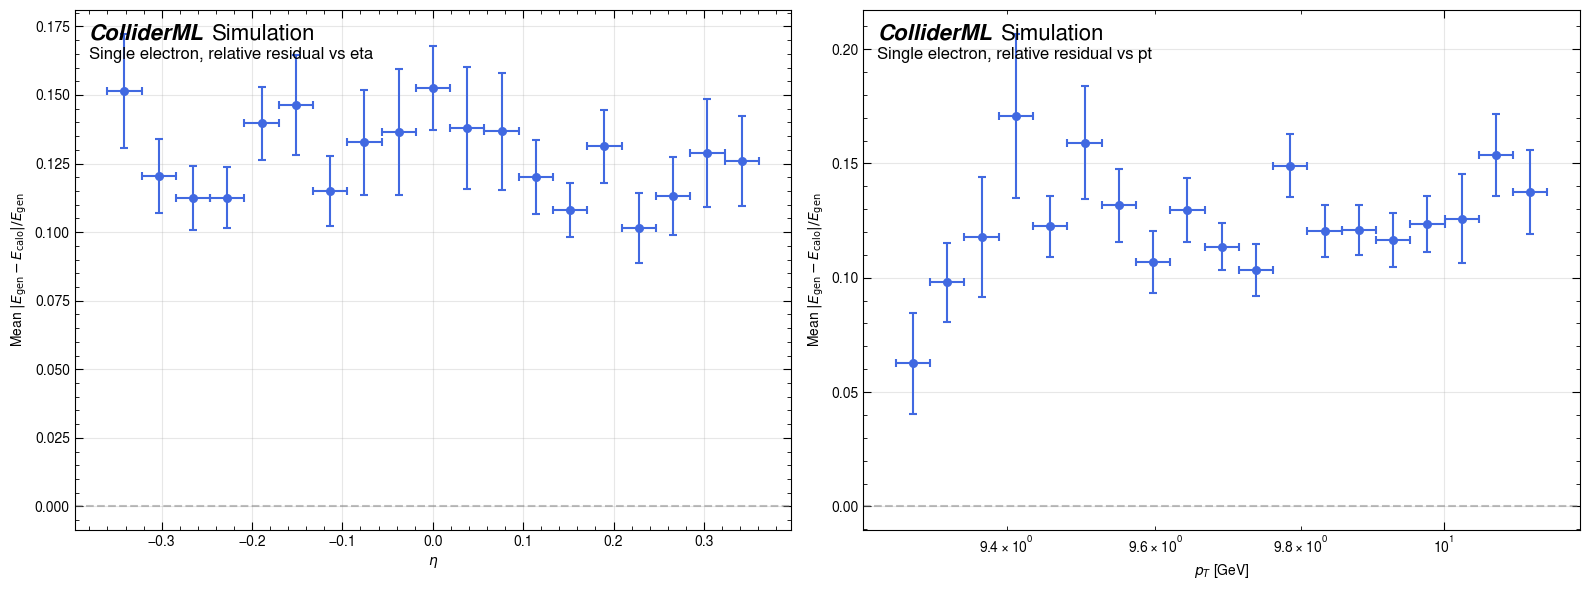

In [50]:
# Profile plots: Mean relative residual vs eta and pt
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Profile 1: Mean relative residual vs eta
eta_bins = np.linspace(combined_pions['eta'].min(), combined_pions['eta'].max(), 20)
eta_bin_centers = []
eta_bin_widths = []
eta_mean_residuals = []
eta_errors = []

for i in range(len(eta_bins)-1):
    mask = (combined_pions['eta'] >= eta_bins[i]) & (combined_pions['eta'] < eta_bins[i+1])
    if mask.sum() > 0:
        eta_bin_centers.append((eta_bins[i] + eta_bins[i+1]) / 2)
        eta_bin_widths.append(eta_bins[i+1] - eta_bins[i])
        residuals_in_bin = relative_residual[mask]
        eta_mean_residuals.append(residuals_in_bin.mean())
        eta_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[0].errorbar(eta_bin_centers, eta_mean_residuals, xerr=np.array(eta_bin_widths)/2, yerr=eta_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[0].set_xlabel(r'$\eta$')
ax[0].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[0].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs eta", axes=ax[0], enlarge=1.0)

# Profile 2: Mean relative residual vs pt (log scale)
pt_bins = np.logspace(np.log10(combined_pions['pt'].min()), 
                       np.log10(combined_pions['pt'].max()), 20)
pt_bin_centers = []
pt_bin_widths = []
pt_mean_residuals = []
pt_errors = []

for i in range(len(pt_bins)-1):
    mask = (combined_pions['pt'] >= pt_bins[i]) & (combined_pions['pt'] < pt_bins[i+1])
    if mask.sum() > 0:
        # Use geometric mean for bin center in log space
        pt_bin_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))
        pt_bin_widths.append(pt_bins[i+1] - pt_bins[i])
        residuals_in_bin = relative_residual[mask]
        pt_mean_residuals.append(residuals_in_bin.mean())
        pt_errors.append(residuals_in_bin.std() / np.sqrt(len(residuals_in_bin)))

ax[1].errorbar(pt_bin_centers, pt_mean_residuals, xerr=np.array(pt_bin_widths)/2, yerr=pt_errors,
               fmt='o', color='royalblue', capsize=3, markersize=5,
               elinewidth=1.5, markeredgewidth=1.5)
ax[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax[1].set_xlabel(r'$p_T$ [GeV]')
ax[1].set_ylabel(r'Mean $|E_{\mathrm{gen}} - E_{\mathrm{calo}}| / E_{\mathrm{gen}}$')
ax[1].set_xscale('log')
ax[1].grid(True, alpha=0.3)
atl.atlasify("Simulation", "Single electron, relative residual vs pt", axes=ax[1], enlarge=1.0)

plt.tight_layout()

## Energy Thresholding Study

In [49]:
def load_edm4hep_data(edm4hep_digi_file, pdg_id, n_events=10000, detector_params=None):
    """
    Load and process EDM4HEP digitized file, extract generator particles of given type.
    
    Parameters
    ----------
    edm4hep_digi_file : str
        Path to digitized EDM4HEP file
    pdg_id : int
        PDG ID of particles to extract (e.g., 11 for electrons, -211 for pi-)
    n_events : int
        Number of events to load
    detector_params : dict, optional
        Detector parameters for EDM4hepEventBatch
    
    Returns
    -------
    dict
        Dictionary with keys: 'calo_digi_hits', 'generator_particles', 'particle_name'
    """
    if detector_params is None:
        detector_params = {
            'tracking_radius': 1080,
            'tracking_z_max': 3030,
            'energy_threshold': 0.
        }
    
    batch = EDM4hepEventBatch(edm4hep_digi_file, events=(0, n_events), 
                             full_load=False, detector_params=detector_params)
    
    calo_digi_hits = batch.get_digi_calo_hits_df()
    calo_sim_hits = batch.get_calo_hits_df()
    particles = batch.get_particles_df()
    
    # Extract generator particles (created_in_simulation == False)
    generator_particles = particles[
        (particles["PDG"] == pdg_id) & 
        (particles["created_in_simulation"] == False)
    ].copy()
    
    # Map PDG ID to particle name
    particle_names = {
        11: "electron",
        -11: "positron",
        211: "pi+",
        -211: "pi-",
        22: "photon"
    }
    particle_name = particle_names.get(pdg_id, f"PDG{pdg_id}")
    
    return {
        'calo_digi_hits': calo_digi_hits,
        'calo_sim_hits': calo_sim_hits,
        'generator_particles': generator_particles,
        'particle_name': particle_name
    }


### Threshold Scanning


In [100]:
def calculate_residuals_for_thresholds(calo_digi_hits, calo_sim_hits, generator_particles, 
                                        ecal_threshold, hcal_threshold):
    """
    Calculate residual metrics using sim-hit thresholds matched to digi-hit energies.
    
    Applies energy thresholds to SIM hits (truth-level), then sums DIGI energies
    for the cells that passed the threshold (matched by event_id and cellID).
    
    Parameters
    ----------
    calo_digi_hits : pd.DataFrame
        Digitized calorimeter hits
    calo_sim_hits : pd.DataFrame
        Simulated (truth-level) calorimeter hits
    generator_particles : pd.DataFrame
        Generator-level particles
    ecal_threshold : float
        Energy threshold for ECal sim hits (GeV)
    hcal_threshold : float
        Energy threshold for HCal sim hits (GeV)
    
    Returns
    -------
    dict
        Dictionary with keys: 'mean_residual', 'std_residual', 'n_events', 
        'energy_sum_mean', 'n_cells_before', 'n_cells_after'
    """
    # Apply thresholds to SIM hits
    ecal_mask_sim = calo_sim_hits['detector'].str.contains('ECal')
    hcal_mask_sim = calo_sim_hits['detector'].str.contains('HCal')
    
    # Count sim cells before threshold
    n_cells_before = len(calo_digi_hits)
    
    # Apply energy thresholds to sim hits
    thresholded_sim = calo_sim_hits[
        ((ecal_mask_sim) & (calo_sim_hits['energy'] >= ecal_threshold)) |
        ((hcal_mask_sim) & (calo_sim_hits['energy'] >= hcal_threshold))
    ].copy()
    
    
    # Merge digi hits with thresholded sim hits on event_id AND cellID
    # This finds all digi energies corresponding to sim cells that passed threshold
    merged = thresholded_sim[['event_id', 'cellID']].merge(
        calo_digi_hits[['event_id', 'cellID', 'energy']], 
        on=['event_id', 'cellID'], 
        how='inner'
    )

    # Count sim cells after threshold
    n_cells_after = len(merged)
    
    # Sum digi energies per event (for cells that passed sim threshold)
    energy_sum = merged.groupby("event_id")["energy"].sum().reset_index(name="energy_sum")
    
    # Merge with generator particles
    combined = generator_particles.merge(energy_sum, left_on="event_id", right_on="event_id", how="inner")
    
    # Calculate residuals
    relative_residual = np.abs(combined["energy"] - combined["energy_sum"]) / combined["energy"]
    
    return {
        'mean_residual': relative_residual.mean(),
        'std_residual': relative_residual.std(),
        'n_events': len(combined),
        'energy_sum_mean': combined["energy_sum"].mean(),
        'n_cells_before': n_cells_before,
        'n_cells_after': n_cells_after
    }


In [101]:
def plot_threshold_scan_heatmaps(scan_df):
    """
    Create 2D heatmaps showing residual, std, cell survival, and cell counts.
    
    Parameters
    ----------
    scan_df : pd.DataFrame
        Results from threshold scan with columns: ecal_threshold, hcal_threshold,
        mean_residual, std_residual, cell_survival_fraction, n_cells_after, n_cells_before
    
    Returns
    -------
    fig, ax
        Matplotlib figure and axes objects
    """
    fig, ax = plt.subplots(2, 2, figsize=(16, 12))
    
    # Pivot for mean residual
    mean_pivot = scan_df.pivot_table(
        values='mean_residual', 
        index='hcal_threshold', 
        columns='ecal_threshold'
    )
    
    im0 = ax[0, 0].imshow(mean_pivot, aspect='auto', origin='lower', cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
    ax[0, 0].set_xlabel('ECal Threshold [GeV]')
    ax[0, 0].set_ylabel('HCal Threshold [GeV]')
    ax[0, 0].set_title('Mean Relative Residual (log scale)')
    ax[0, 0].set_xticklabels([f'{t:.0e}' for t in mean_pivot.columns[::2]], rotation=45)
    ax[0, 0].set_yticklabels([f'{t:.0e}' for t in mean_pivot.index[::2]])
    cbar0 = plt.colorbar(im0, ax=ax[0, 0])
    
    # Pivot for std residual
    std_pivot = scan_df.pivot_table(
        values='std_residual', 
        index='hcal_threshold', 
        columns='ecal_threshold'
    )
    
    im1 = ax[0, 1].imshow(std_pivot, aspect='auto', origin='lower', cmap='plasma')
    ax[0, 1].set_xlabel('ECal Threshold [GeV]')
    ax[0, 1].set_ylabel('HCal Threshold [GeV]')
    ax[0, 1].set_title('Std Dev of Relative Residual')
    ax[0, 1].set_xticklabels([f'{t:.0e}' for t in std_pivot.columns[::2]], rotation=45)
    ax[0, 1].set_yticklabels([f'{t:.0e}' for t in std_pivot.index[::2]])
    cbar1 = plt.colorbar(im1, ax=ax[0, 1])
    
    # Pivot for cell survival fraction
    survival_pivot = scan_df.pivot_table(
        values='cell_survival_fraction', 
        index='hcal_threshold', 
        columns='ecal_threshold'
    )
    
    im2 = ax[1, 0].imshow(survival_pivot, aspect='auto', origin='lower', cmap='RdYlGn')
    ax[1, 0].set_xlabel('ECal Threshold [GeV]')
    ax[1, 0].set_ylabel('HCal Threshold [GeV]')
    ax[1, 0].set_title('Cell Survival Fraction (after threshold)')
    ax[1, 0].set_xticklabels([f'{t:.0e}' for t in survival_pivot.columns[::2]], rotation=45)
    ax[1, 0].set_yticklabels([f'{t:.0e}' for t in survival_pivot.index[::2]])
    cbar2 = plt.colorbar(im2, ax=ax[1, 0])
    
    # Pivot for number of cells after threshold
    n_cells_pivot = scan_df.pivot_table(
        values='n_cells_after', 
        index='hcal_threshold', 
        columns='ecal_threshold'
    )
    
    im3 = ax[1, 1].imshow(n_cells_pivot, aspect='auto', origin='lower', cmap='hot')
    ax[1, 1].set_xlabel('ECal Threshold [GeV]')
    ax[1, 1].set_ylabel('HCal Threshold [GeV]')
    ax[1, 1].set_title(f'Number of Cells After Threshold (total before: {scan_df.iloc[0]["n_cells_before"]:.0f})')
    ax[1, 1].set_xticklabels([f'{t:.0e}' for t in n_cells_pivot.columns[::2]], rotation=45)
    ax[1, 1].set_yticklabels([f'{t:.0e}' for t in n_cells_pivot.index[::2]])
    cbar3 = plt.colorbar(im3, ax=ax[1, 1])
    
    plt.tight_layout()
    return fig, ax


def plot_threshold_scan_profiles(scan_df, ecal_thresholds, hcal_thresholds):
    """
    Create profile plots showing residuals and cell survival as functions vary.
    
    Parameters
    ----------
    scan_df : pd.DataFrame
        Results from threshold scan
    ecal_thresholds : array-like
        ECal threshold values used in scan
    hcal_thresholds : array-like
        HCal threshold values used in scan
    
    Returns
    -------
    fig, ax
        Matplotlib figure and axes objects
    """
    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    
    # Fix HCal threshold at median value and vary ECal
    hcal_fixed = hcal_thresholds[len(hcal_thresholds)//2]
    subset1 = scan_df[scan_df['hcal_threshold'] == hcal_fixed].sort_values('ecal_threshold')
    
    ax[0, 0].errorbar(subset1['ecal_threshold'], subset1['mean_residual'], 
                   yerr=subset1['std_residual']/np.sqrt(subset1['n_events']),
                   fmt='o-', color='royalblue', capsize=3, markersize=6)
    ax[0, 0].set_xlabel('ECal Threshold [GeV]')
    ax[0, 0].set_ylabel('Mean Relative Residual')
    ax[0, 0].set_xscale('log')
    ax[0, 0].grid(True, alpha=0.3)
    ax[0, 0].set_title(f'Varying ECal (HCal = {hcal_fixed:.2e} GeV)')
    atl.atlasify("Simulation", "Threshold scan", axes=ax[0, 0], enlarge=1.0)
    
    # Cell survival fraction for varying ECal
    ax[0, 1].plot(subset1['ecal_threshold'], subset1['cell_survival_fraction']*100, 
                  'o-', color='darkred', markersize=6, linewidth=2)
    ax[0, 1].set_xlabel('ECal Threshold [GeV]')
    ax[0, 1].set_ylabel('Cell Survival Fraction (%)')
    ax[0, 1].set_xscale('log')
    ax[0, 1].grid(True, alpha=0.3)
    ax[0, 1].set_title(f'Cell Survival vs ECal Threshold (HCal = {hcal_fixed:.2e} GeV)')
    atl.atlasify("Simulation", "Threshold scan", axes=ax[0, 1], enlarge=1.0)
    
    # Fix ECal threshold at median value and vary HCal
    ecal_fixed = ecal_thresholds[len(ecal_thresholds)//2]
    subset2 = scan_df[scan_df['ecal_threshold'] == ecal_fixed].sort_values('hcal_threshold')
    
    ax[1, 0].errorbar(subset2['hcal_threshold'], subset2['mean_residual'], 
                   yerr=subset2['std_residual']/np.sqrt(subset2['n_events']),
                   fmt='s-', color='darkgreen', capsize=3, markersize=6)
    ax[1, 0].set_xlabel('HCal Threshold [GeV]')
    ax[1, 0].set_ylabel('Mean Relative Residual')
    ax[1, 0].set_xscale('log')
    ax[1, 0].grid(True, alpha=0.3)
    ax[1, 0].set_title(f'Varying HCal (ECal = {ecal_fixed:.2e} GeV)')
    atl.atlasify("Simulation", "Threshold scan", axes=ax[1, 0], enlarge=1.0)
    
    # Cell survival fraction for varying HCal
    ax[1, 1].plot(subset2['hcal_threshold'], subset2['cell_survival_fraction']*100, 
                  's-', color='darkorange', markersize=6, linewidth=2)
    ax[1, 1].set_xlabel('HCal Threshold [GeV]')
    ax[1, 1].set_ylabel('Cell Survival Fraction (%)')
    ax[1, 1].set_xscale('log')
    ax[1, 1].grid(True, alpha=0.3)
    ax[1, 1].set_title(f'Cell Survival vs HCal Threshold (ECal = {ecal_fixed:.2e} GeV)')
    atl.atlasify("Simulation", "Threshold scan", axes=ax[1, 1], enlarge=1.0)
    
    plt.tight_layout()
    return fig, ax

### Electrons

In [105]:
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

electron_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_electron_loguniform/v1/runs/0/edm4hep_digitized.root"
data = load_edm4hep_data(electron_file, pdg_id=11, n_events=10000)
calo_digi_hits = data['calo_digi_hits']
calo_sim_hits = data['calo_sim_hits']
generator_particles = data['generator_particles']
particle_name = data['particle_name']

In [106]:
# Define threshold scan ranges
ecal_thresholds = np.logspace(np.log10(0.00005), np.log10(0.01), 20)  # 0.00001 to 0.001 GeV
hcal_thresholds = np.logspace(np.log10(0.00025), np.log10(0.00025), 3)  # 0.0001 to 0.01 GeV

# Run scan
scan_results = []
for ecal_th in tqdm(ecal_thresholds, desc="Scanning ECal thresholds"):
    for hcal_th in hcal_thresholds:
        metrics = calculate_residuals_for_thresholds(
            calo_digi_hits, calo_sim_hits, generator_particles, ecal_th, hcal_th
        )
        scan_results.append({
            'ecal_threshold': ecal_th,
            'hcal_threshold': hcal_th,
            'mean_residual': metrics['mean_residual'],
            'std_residual': metrics['std_residual'],
            'n_events': metrics['n_events'],
            'energy_sum_mean': metrics['energy_sum_mean'],
            'n_cells_before': metrics['n_cells_before'],
            'n_cells_after': metrics['n_cells_after']
        })

scan_df = pd.DataFrame(scan_results)
# Calculate cell survival fraction (cells that pass threshold)
scan_df['cell_survival_fraction'] = scan_df['n_cells_after'] / scan_df['n_cells_before']
scan_df


Scanning ECal thresholds:   0%|          | 0/20 [00:00<?, ?it/s]

Scanning ECal thresholds: 100%|██████████| 20/20 [00:42<00:00,  2.10s/it]


,ecal_threshold,hcal_threshold,mean_residual,std_residual,n_events,energy_sum_mean,n_cells_before,n_cells_after,cell_survival_fraction
0,0.000050,0.00025,0.177143,0.261154,952,94.676193,1252753,1252237,0.999588
1,0.000050,0.00025,0.177143,0.261154,952,94.676193,1252753,1252237,0.999588
2,0.000050,0.00025,0.177143,0.261154,952,94.676193,1252753,1252237,0.999588
3,0.000066,0.00025,0.177180,0.261312,952,94.607025,1252753,1222251,0.975652
4,0.000066,0.00025,0.177180,0.261312,952,94.607025,1252753,1222251,0.975652
5,0.000066,0.00025,0.177180,0.261312,952,94.607025,1252753,1222251,0.975652
6,0.000087,0.00025,0.177291,0.261613,952,94.492256,1252753,1184509,0.945525
7,0.000087,0.00025,0.177291,0.261613,952,94.492256,1252753,1184509,0.945525
8,0.000087,0.00025,0.177291,0.261613,952,94.492256,1252753,1184509,0.945525
9,0.000115,0.00025,0.177735,0.261930,952,94.309364,1252753,1139119,0.909293


/tmp/ipykernel_1573462/723457431.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_xticklabels([f'{t:.0e}' for t in mean_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_yticklabels([f'{t:.0e}' for t in mean_pivot.index[::2]])
/tmp/ipykernel_1573462/723457431.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_xticklabels([f'{t:.0e}' for t in std_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_yticklabels([f'{t:.0e}' for t in std_pivot.index[::2]])
/tmp/ipykern

/tmp/ipykernel_1573462/723457431.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1, 1].set_xticklabels([f'{t:.0e}' for t in n_cells_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1, 1].set_yticklabels([f'{t:.0e}' for t in n_cells_pivot.index[::2]])


(<Figure size 1600x1200 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Relative Residual (log scale)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Std Dev of Relative Residual'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>],
        [<Axes: title={'center': 'Cell Survival Fraction (after threshold)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Number of Cells After Threshold (total before: 1252753)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>]],
       dtype=object))

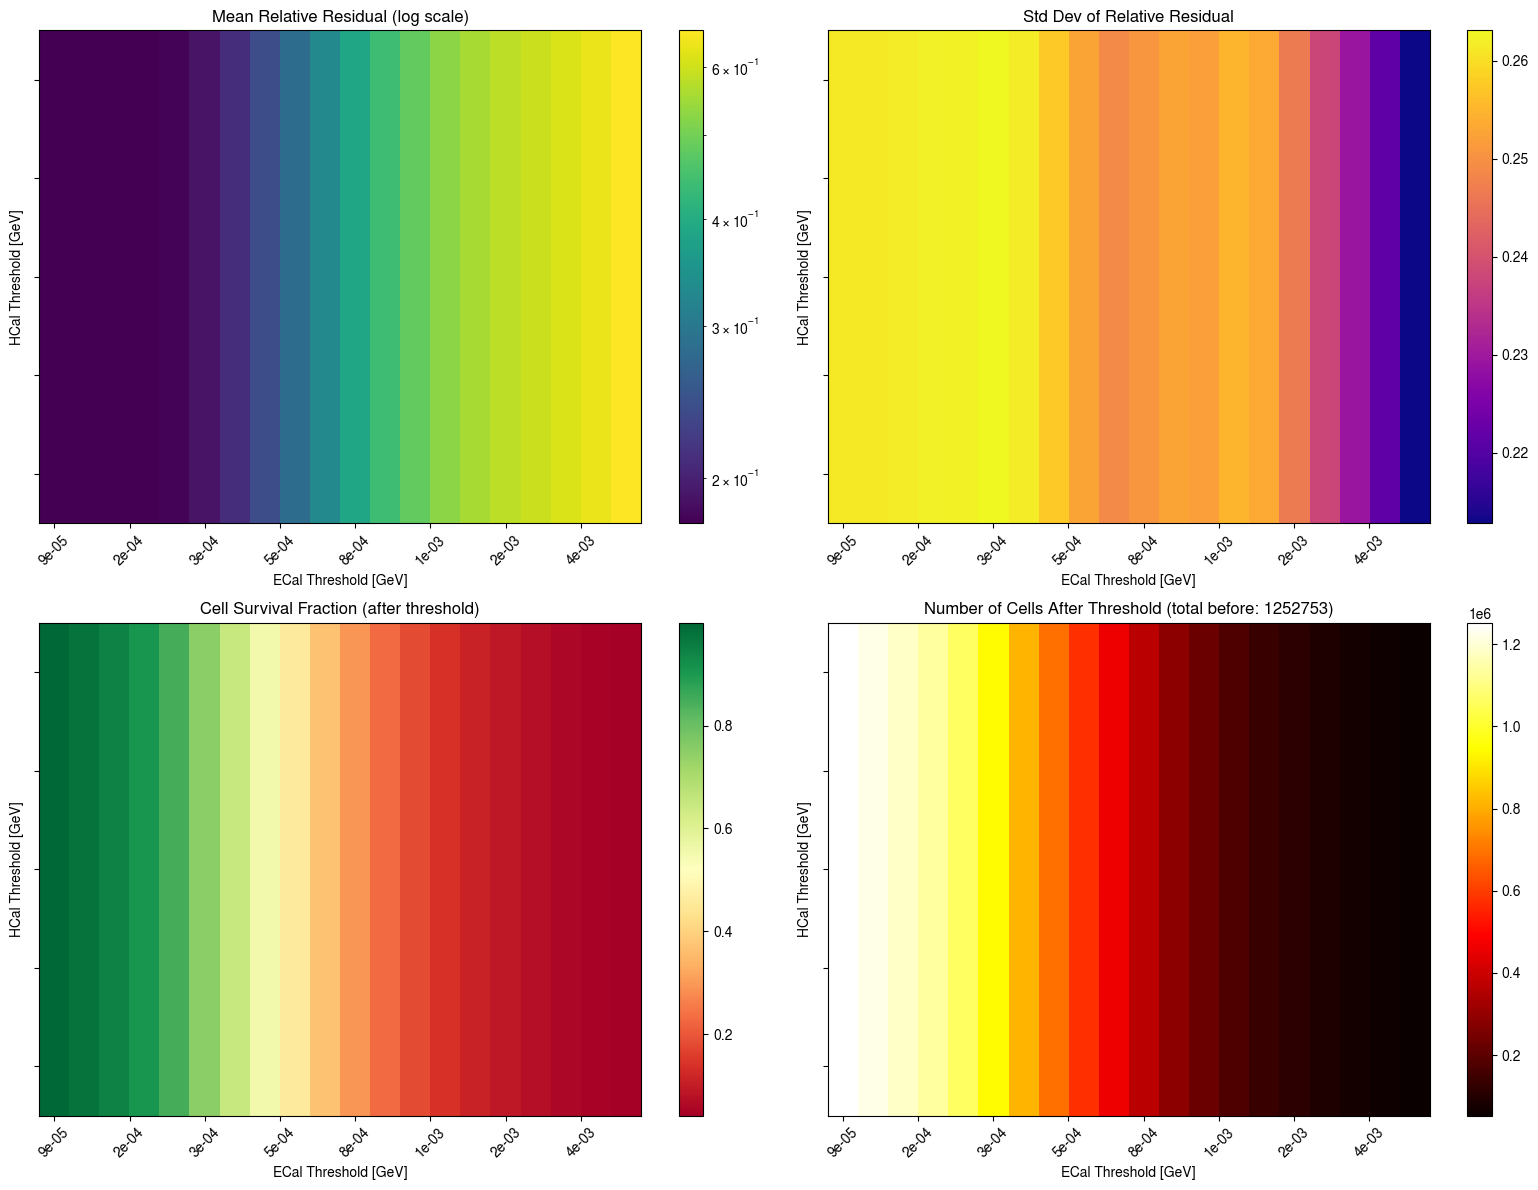

In [107]:
plot_threshold_scan_heatmaps(scan_df)


(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Varying ECal (HCal = 2.50e-04 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs ECal Threshold (HCal = 2.50e-04 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>],
        [<Axes: title={'center': 'Varying HCal (ECal = 8.13e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs HCal Threshold (ECal = 8.13e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>]],
       dtype=object))

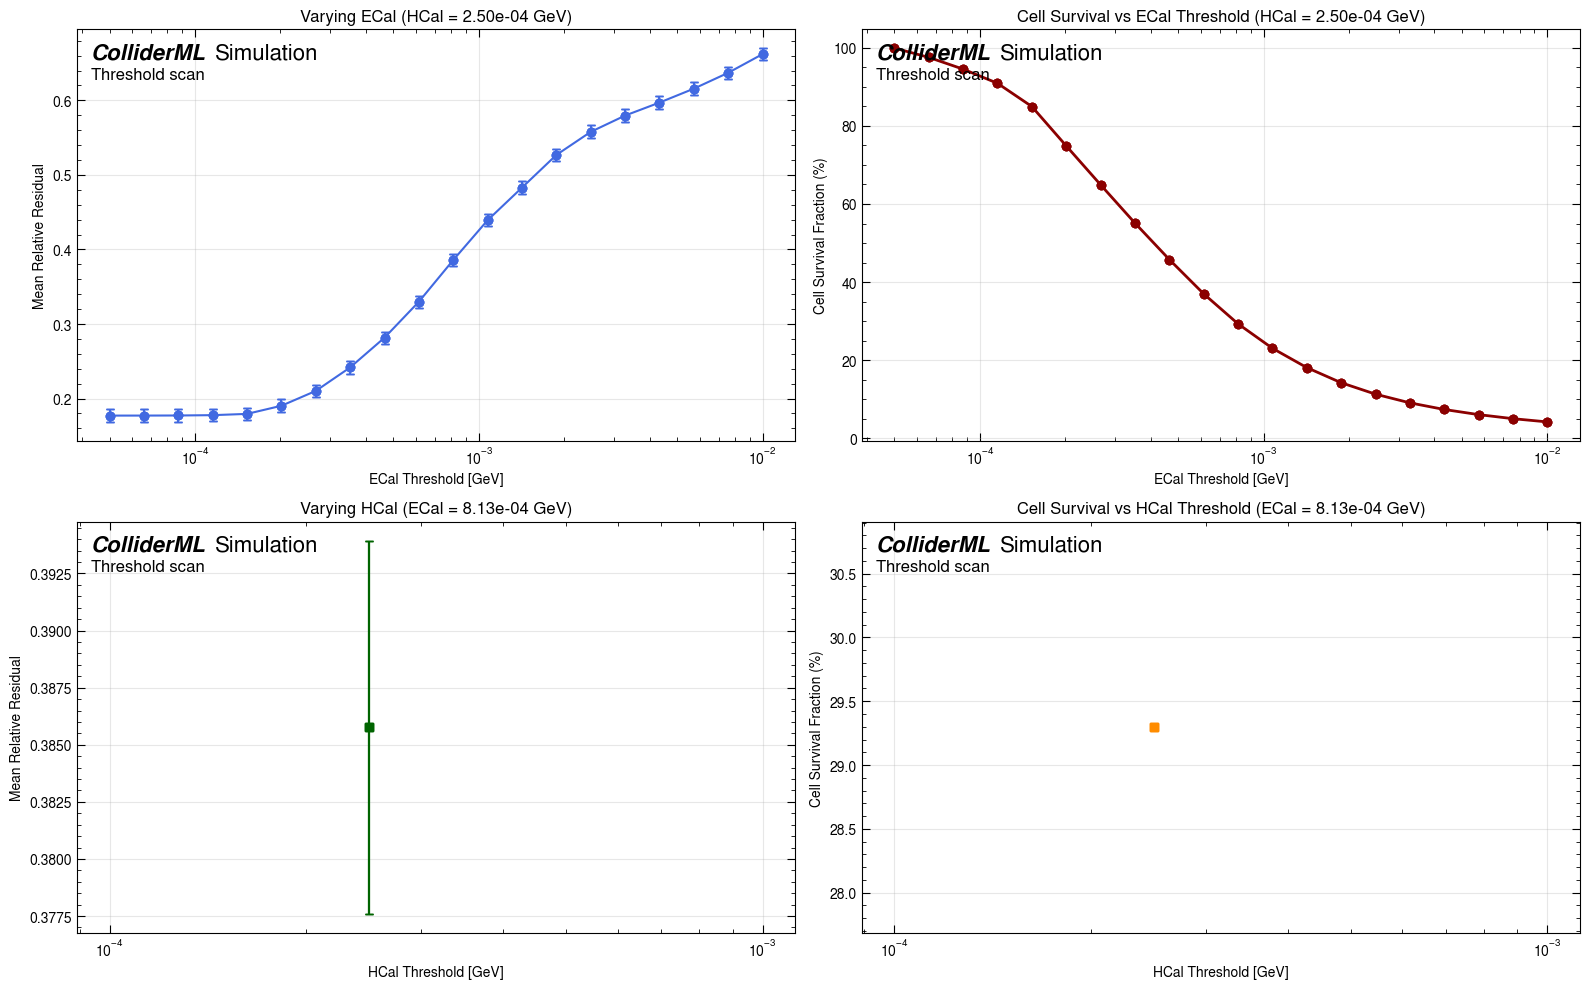

In [108]:
plot_threshold_scan_profiles(scan_df, ecal_thresholds, hcal_thresholds)

### Photons

In [109]:
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

photon_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_photon_loguniform/v1/runs/0/edm4hep_digitized.root"
data = load_edm4hep_data(photon_file, pdg_id=22, n_events=10000)
calo_digi_hits = data['calo_digi_hits']
calo_sim_hits = data['calo_sim_hits']
generator_particles = data['generator_particles']
particle_name = data['particle_name']

In [110]:
# Define threshold scan ranges
ecal_thresholds = np.logspace(np.log10(0.00005), np.log10(0.001), 10)  # 0.00001 to 0.001 GeV
hcal_thresholds = np.logspace(np.log10(0.00025), np.log10(0.00025), 3)  # 0.0001 to 0.01 GeV

# Run scan
scan_results = []
for ecal_th in tqdm(ecal_thresholds, desc="Scanning ECal thresholds"):
    for hcal_th in hcal_thresholds:
        metrics = calculate_residuals_for_thresholds(
            calo_digi_hits, calo_sim_hits, generator_particles, ecal_th, hcal_th
        )
        scan_results.append({
            'ecal_threshold': ecal_th,
            'hcal_threshold': hcal_th,
            'mean_residual': metrics['mean_residual'],
            'std_residual': metrics['std_residual'],
            'n_events': metrics['n_events'],
            'energy_sum_mean': metrics['energy_sum_mean'],
            'n_cells_before': metrics['n_cells_before'],
            'n_cells_after': metrics['n_cells_after']
        })

scan_df = pd.DataFrame(scan_results)
# Calculate cell survival fraction (cells that pass threshold)
scan_df['cell_survival_fraction'] = scan_df['n_cells_after'] / scan_df['n_cells_before']
scan_df

Scanning ECal thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

Scanning ECal thresholds: 100%|██████████| 10/10 [07:00<00:00, 42.08s/it]


,ecal_threshold,hcal_threshold,mean_residual,std_residual,n_events,energy_sum_mean,n_cells_before,n_cells_after,cell_survival_fraction
0,0.000050,0.00025,0.133858,0.207566,9654,117.328209,13465571,13465571,1.000000
1,0.000050,0.00025,0.133858,0.207566,9654,117.328209,13465571,13465571,1.000000
2,0.000050,0.00025,0.133858,0.207566,9654,117.328209,13465571,13465571,1.000000
3,0.000070,0.00025,0.133711,0.207791,9654,117.233322,13465571,13059247,0.969825
4,0.000070,0.00025,0.133711,0.207791,9654,117.233322,13465571,13059247,0.969825
5,0.000070,0.00025,0.133711,0.207791,9654,117.233322,13465571,13059247,0.969825
6,0.000097,0.00025,0.133454,0.208101,9654,117.064041,13465571,12539875,0.931255
7,0.000097,0.00025,0.133454,0.208101,9654,117.064041,13465571,12539875,0.931255
8,0.000097,0.00025,0.133454,0.208101,9654,117.064041,13465571,12539875,0.931255
9,0.000136,0.00025,0.133367,0.208438,9652,116.771851,13465571,11849320,0.879972


/tmp/ipykernel_1573462/723457431.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_xticklabels([f'{t:.0e}' for t in mean_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_yticklabels([f'{t:.0e}' for t in mean_pivot.index[::2]])
/tmp/ipykernel_1573462/723457431.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_xticklabels([f'{t:.0e}' for t in std_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_yticklabels([f'{t:.0e}' for t in std_pivot.index[::2]])
/tmp/ipykern

(<Figure size 1600x1200 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Relative Residual (log scale)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Std Dev of Relative Residual'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>],
        [<Axes: title={'center': 'Cell Survival Fraction (after threshold)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Number of Cells After Threshold (total before: 13465571)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>]],
       dtype=object))

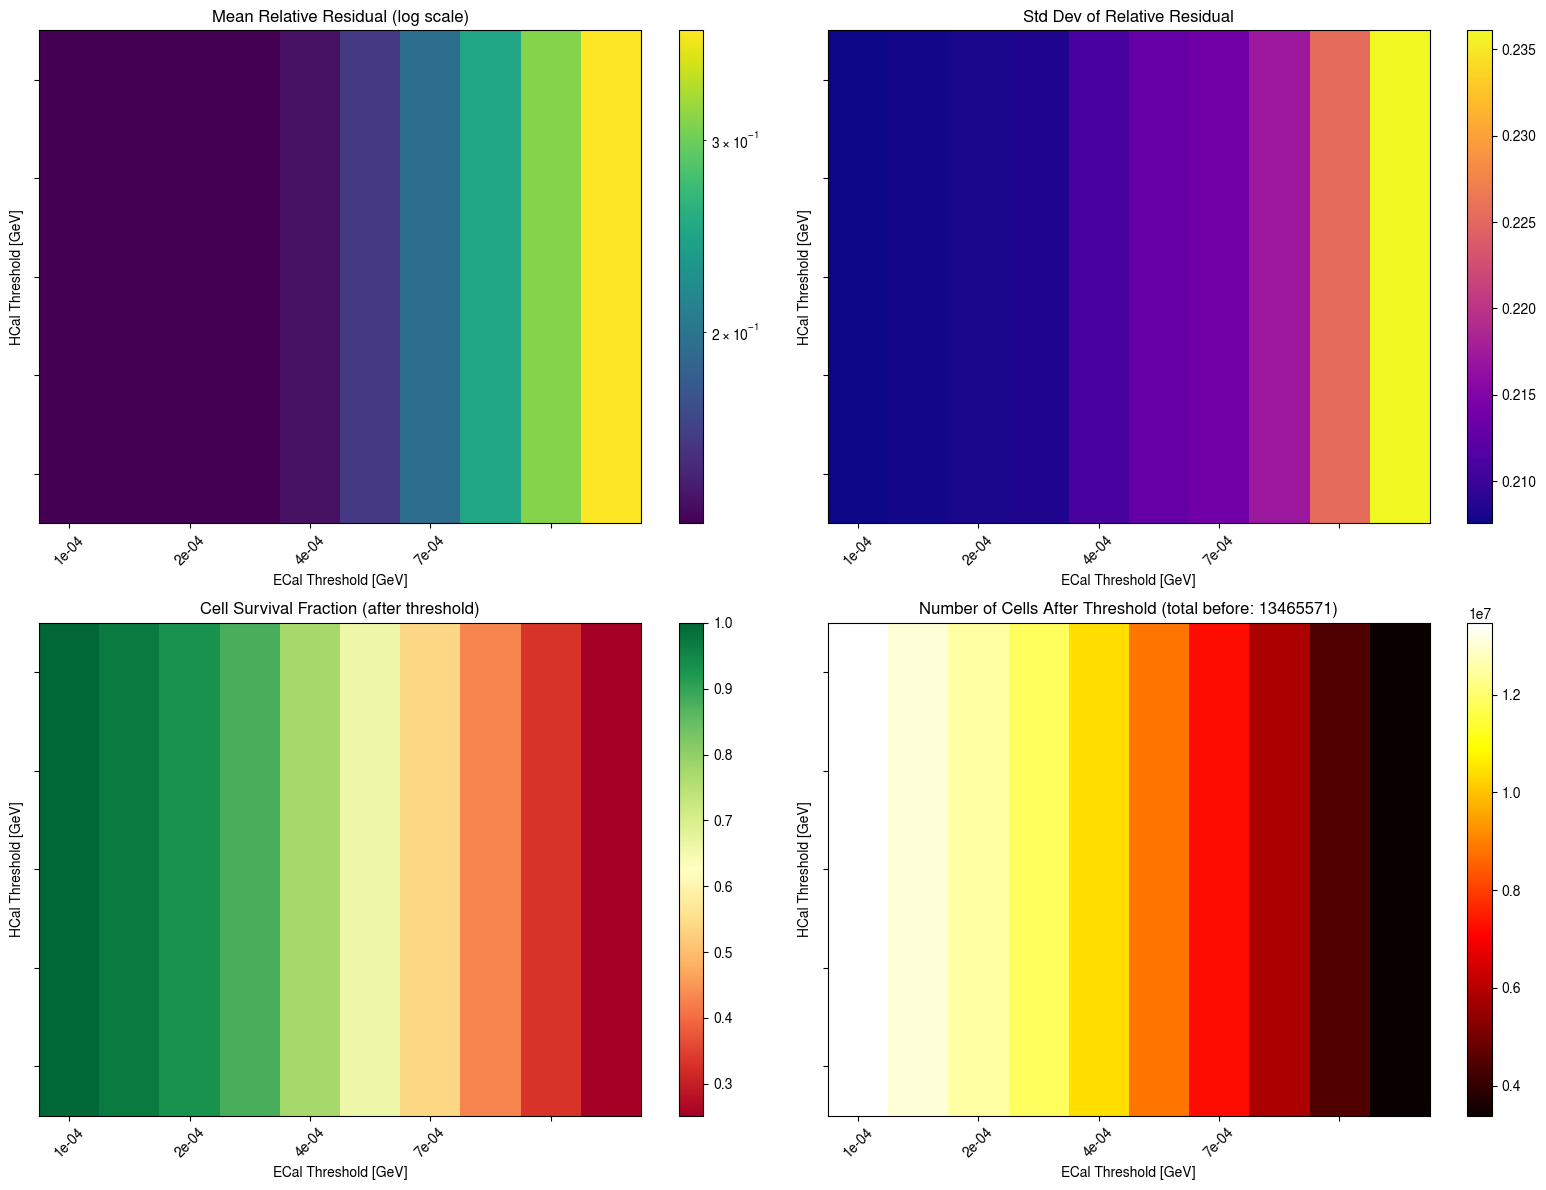

In [111]:
plot_threshold_scan_heatmaps(scan_df)


(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Varying ECal (HCal = 2.50e-04 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs ECal Threshold (HCal = 2.50e-04 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>],
        [<Axes: title={'center': 'Varying HCal (ECal = 2.64e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs HCal Threshold (ECal = 2.64e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>]],
       dtype=object))

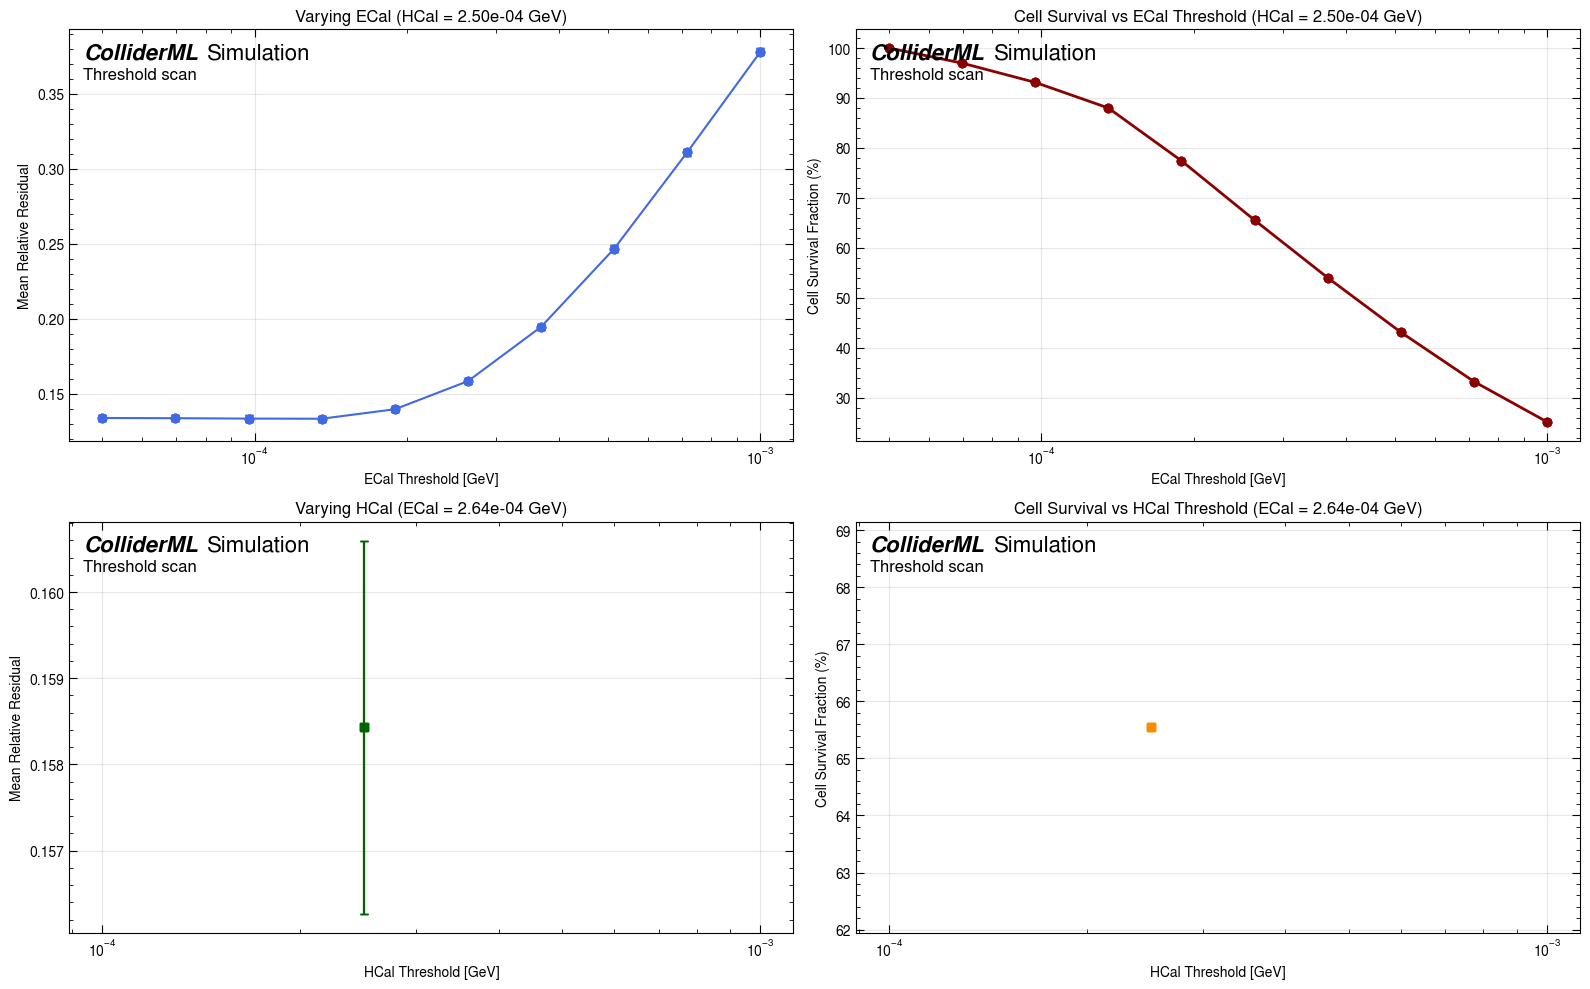

In [112]:
plot_threshold_scan_profiles(scan_df, ecal_thresholds, hcal_thresholds)

### Pions

In [113]:
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

pion_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/single_particle_pilot/single_pion_loguniform/v1/runs/0/edm4hep_digitized.root"
data = load_edm4hep_data(pion_file, pdg_id=-211, n_events=10000)
calo_digi_hits = data['calo_digi_hits']
calo_sim_hits = data['calo_sim_hits']
generator_particles = data['generator_particles']
particle_name = data['particle_name']

In [114]:
# Define threshold scan ranges
ecal_thresholds = np.logspace(np.log10(0.00005), np.log10(0.001), 10)  # 0.00001 to 0.001 GeV
hcal_thresholds = np.logspace(np.log10(0.00025), np.log10(0.02), 10)  # 0.0001 to 0.01 GeV

# Run scan
scan_results = []
for ecal_th in tqdm(ecal_thresholds, desc="Scanning ECal thresholds"):
    for hcal_th in hcal_thresholds:
        metrics = calculate_residuals_for_thresholds(
            calo_digi_hits, calo_sim_hits, generator_particles, ecal_th, hcal_th
        )
        scan_results.append({
            'ecal_threshold': ecal_th,
            'hcal_threshold': hcal_th,
            'mean_residual': metrics['mean_residual'],
            'std_residual': metrics['std_residual'],
            'n_events': metrics['n_events'],
            'energy_sum_mean': metrics['energy_sum_mean'],
            'n_cells_before': metrics['n_cells_before'],
            'n_cells_after': metrics['n_cells_after']
        })

scan_df = pd.DataFrame(scan_results)
# Calculate cell survival fraction (cells that pass threshold)
scan_df['cell_survival_fraction'] = scan_df['n_cells_after'] / scan_df['n_cells_before']
scan_df

Scanning ECal thresholds:   0%|          | 0/10 [00:00<?, ?it/s]

Scanning ECal thresholds: 100%|██████████| 10/10 [01:39<00:00,  9.93s/it]


,ecal_threshold,hcal_threshold,mean_residual,std_residual,n_events,energy_sum_mean,n_cells_before,n_cells_after,cell_survival_fraction
0,0.00005,0.000250,0.408239,0.232962,926,52.918728,853621,851139,0.997092
1,0.00005,0.000407,0.410348,0.232839,925,52.738750,853621,837194,0.980756
2,0.00005,0.000662,0.420245,0.233072,915,52.399437,853621,803131,0.940852
3,0.00005,0.001077,0.432004,0.232717,900,51.587013,853621,763037,0.893883
4,0.00005,0.001753,0.450507,0.237923,890,49.837589,853621,728879,0.853867
...,...,...,...,...,...,...,...,...,...
95,0.00100,0.002852,0.647683,0.179765,839,41.673000,853621,172208,0.201738
96,0.00100,0.004642,0.669940,0.184290,830,38.854580,853621,155413,0.182063
97,0.00100,0.007553,0.690564,0.190732,813,36.082260,853621,144574,0.169366
98,0.00100,0.012291,0.711588,0.197953,802,32.817532,853621,137983,0.161644


/tmp/ipykernel_1573462/723457431.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_xticklabels([f'{t:.0e}' for t in mean_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 0].set_yticklabels([f'{t:.0e}' for t in mean_pivot.index[::2]])
/tmp/ipykernel_1573462/723457431.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_xticklabels([f'{t:.0e}' for t in std_pivot.columns[::2]], rotation=45)
/tmp/ipykernel_1573462/723457431.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0, 1].set_yticklabels([f'{t:.0e}' for t in std_pivot.index[::2]])
/tmp/ipykern

(<Figure size 1600x1200 with 8 Axes>,
 array([[<Axes: title={'center': 'Mean Relative Residual (log scale)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Std Dev of Relative Residual'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>],
        [<Axes: title={'center': 'Cell Survival Fraction (after threshold)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>,
         <Axes: title={'center': 'Number of Cells After Threshold (total before: 853621)'}, xlabel='ECal Threshold [GeV]', ylabel='HCal Threshold [GeV]'>]],
       dtype=object))

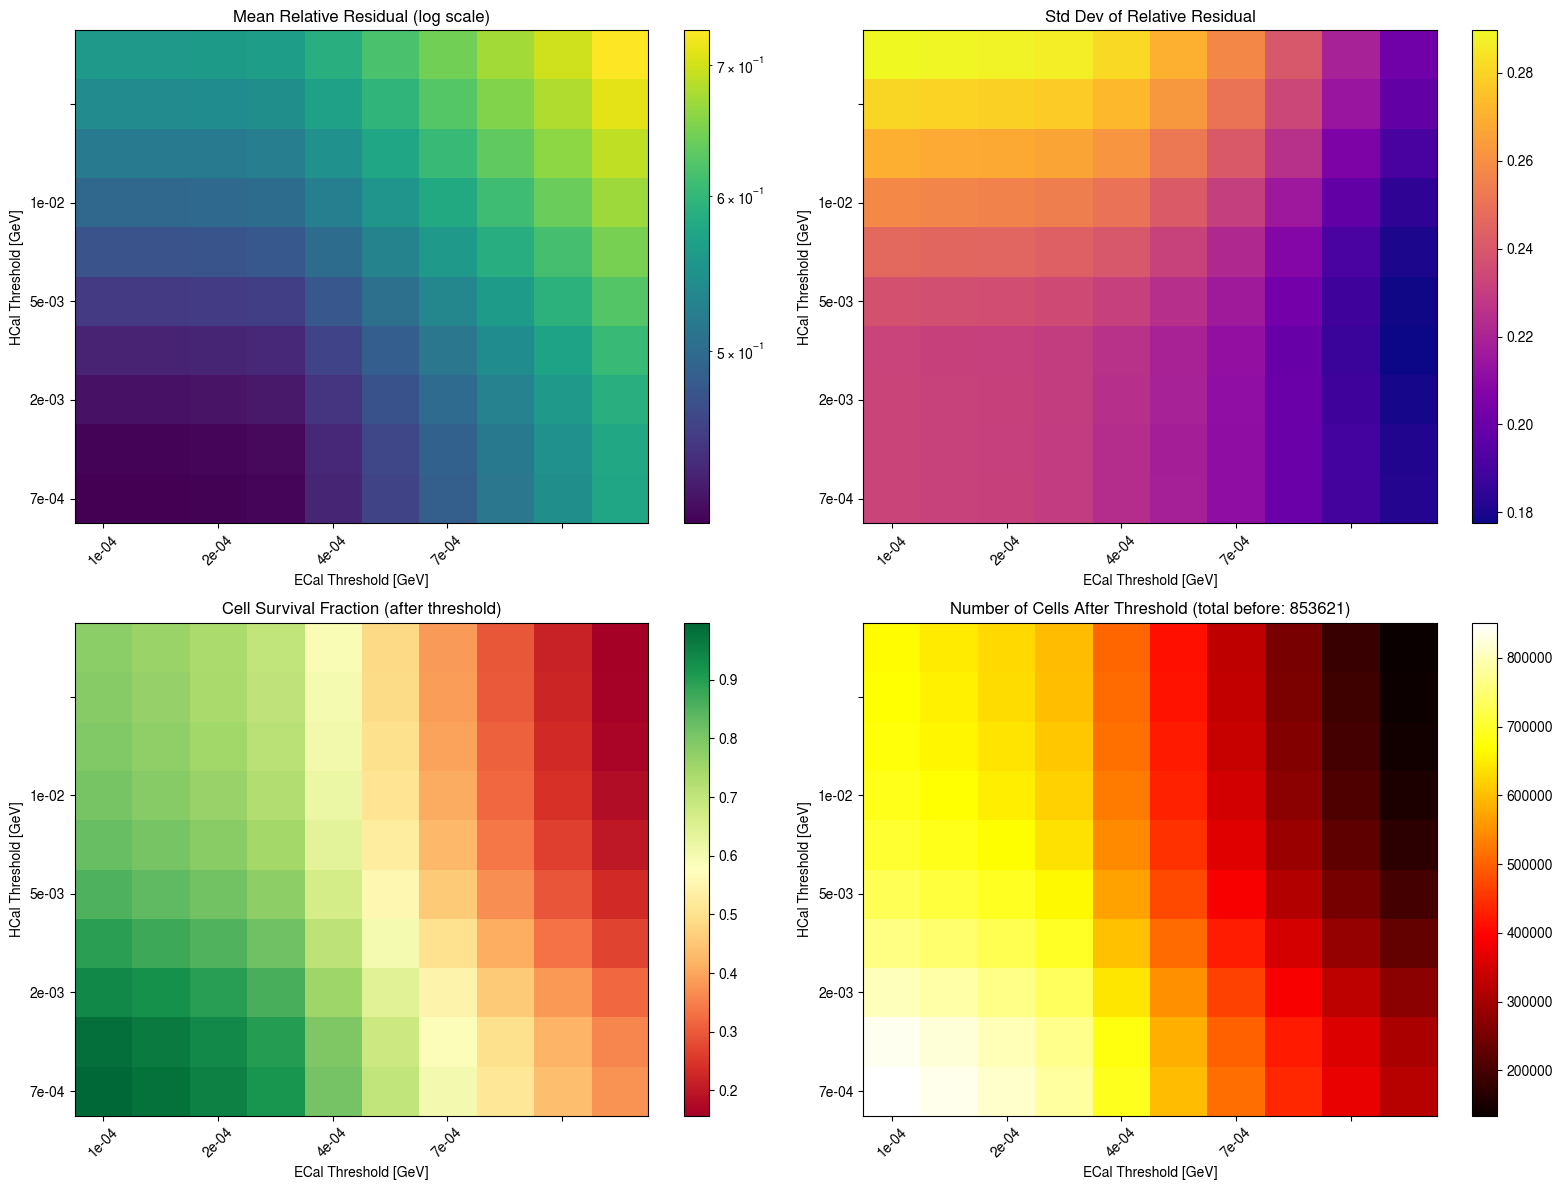

In [115]:
plot_threshold_scan_heatmaps(scan_df)


(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Varying ECal (HCal = 2.85e-03 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs ECal Threshold (HCal = 2.85e-03 GeV)'}, xlabel='ECal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>],
        [<Axes: title={'center': 'Varying HCal (ECal = 2.64e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Mean Relative Residual'>,
         <Axes: title={'center': 'Cell Survival vs HCal Threshold (ECal = 2.64e-04 GeV)'}, xlabel='HCal Threshold [GeV]', ylabel='Cell Survival Fraction (%)'>]],
       dtype=object))

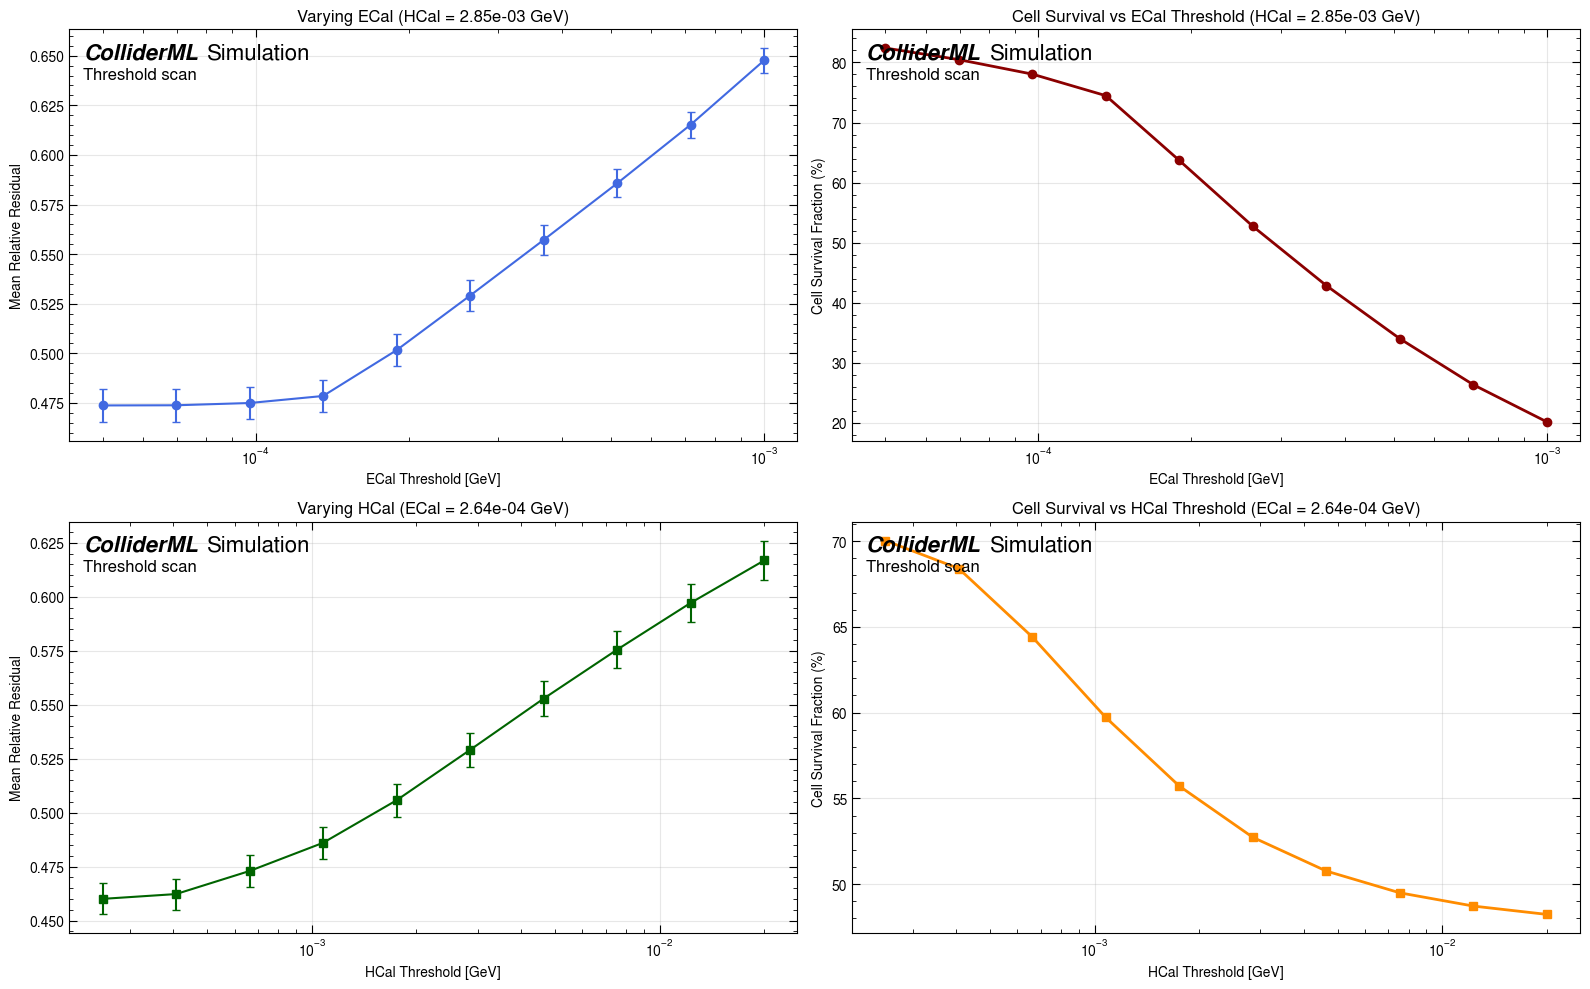

In [116]:
plot_threshold_scan_profiles(scan_df, ecal_thresholds, hcal_thresholds)

In [75]:
data

{'calo_digi_hits':         event_id  subentry                cellID    energy  energy_error  \
 0              5         0  18436610841420845072  0.005988           0.0   
 1              5         1  18436610841420910608  0.005096           0.0   
 2              5         2  18436329370739232784  0.006988           0.0   
 3              5         3  18436329370739298320  0.004990           0.0   
 4              5         4  18436329370739363856  0.005091           0.0   
 ...          ...       ...                   ...       ...           ...   
 853616       998        30  18442803406868662548  0.021878           0.0   
 853617       998        31  18442803406868728084  0.042013           0.0   
 853618       998        32  18442521931892082964  0.024982           0.0   
 853619       998        33  18441114561303496980  0.148901           0.0   
 853620       998        34  18439707190714845460  0.105114           0.0   
 
             time           x            y            z 

In [76]:
calo_digi_hits

,event_id,subentry,cellID,energy,energy_error,time,x,y,z,type,detector,r,R,phi,theta,eta
0,5,0,18436610841420845072,0.005988,0.0,0.318063,158.100006,1252.400024,-188.699997,11010,digiECalBarrelCollection,1262.339722,1276.365601,1.445223,1.719182,-0.148933
1,5,1,18436610841420910608,0.005096,0.0,0.319594,158.100006,1257.449951,-188.699997,21010,digiECalBarrelCollection,1267.349976,1281.321045,1.445722,1.718604,-0.148349
2,5,2,18436329370739232784,0.006988,0.0,0.320686,153.000000,1262.500000,-193.800003,31010,digiECalBarrelCollection,1271.737061,1286.418945,1.450196,1.722023,-0.151806
3,5,3,18436329370739298320,0.004990,0.0,0.322224,153.000000,1267.550049,-193.800003,41010,digiECalBarrelCollection,1276.750610,1291.375488,1.450672,1.721438,-0.151215
4,5,4,18436329370739363856,0.005091,0.0,0.323796,153.000000,1272.599976,-193.800003,51010,digiECalBarrelCollection,1281.764282,1296.332642,1.451144,1.720858,-0.150628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853616,998,30,18442803406868662548,0.021878,0.0,0.236813,-429.670624,1350.891846,3851.500000,52021,digiHCalEndcapCollection,1417.577393,4104.092773,1.878742,0.352671,1.724926
853617,998,31,18442803406868728084,0.042013,0.0,0.308764,-429.670624,1350.891846,3902.500000,62021,digiHCalEndcapCollection,1417.577393,4151.991211,1.878742,0.348428,1.737280
853618,998,32,18442521931892082964,0.024982,0.0,1.203177,-418.190125,1323.175415,3953.500000,72021,digiHCalEndcapCollection,1387.687378,4189.968750,1.876912,0.337567,1.769578
853619,998,33,18441114561303496980,0.148901,0.0,7.876475,-388.503998,1173.112915,3953.500000,72021,digiHCalEndcapCollection,1235.770752,4142.136230,1.890602,0.302954,1.879630


In [82]:
calo_sim_hits = calo_sim_hits.rename(columns={"energy": "sim_energy"})

In [84]:
calo_digi_hits = calo_digi_hits.merge(calo_sim_hits[["event_id", "cellID", "sim_energy"]], on=["event_id", "cellID"])

<Axes: xlabel='sim_energy', ylabel='Count'>

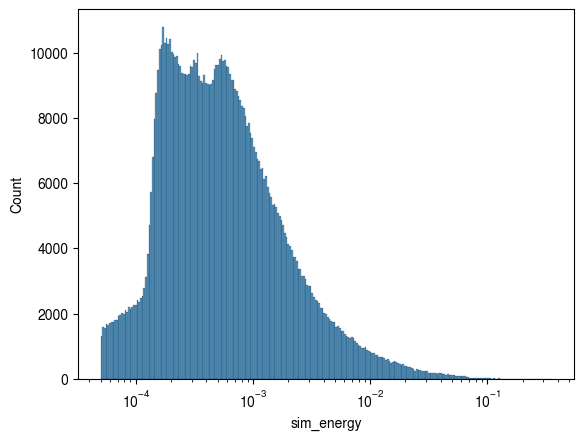

In [88]:
sns.histplot(calo_digi_hits["sim_energy"], log_scale=True)

In [89]:
ecal_thresholds

array([5.00000000e-08, 1.94076672e-07, 7.53315095e-07, 2.92401774e-06,
       1.13496727e-05, 4.40541340e-05, 1.70997595e-04, 6.63732883e-04,
       2.57630139e-03, 1.00000000e-02])

In [90]:
hcal_thresholds

array([0.00025])